# PBCO historgram plot of all the modes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle
import pandas as pd
import tensorflow as tf
from importlib import reload
import P2_alris_one_third_functions as P2_alris_one_third_functions
reload(P2_alris_one_third_functions)
from P2_alris_one_third_functions import shift_atoms, transform_list_hkl_p63_p65, get_structure_factors , atom_position_list

number_of_modes = 52

structure_type = 'P2'
path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type


In [3]:
def fn_all_hkl_list():
    all_h_list = np.linspace(0 , -4.666666 , 15)
    all_k_list = np.linspace(0 , 4.666666 , 15) 
    all_l_list = np.linspace(0 , 12 , 5) 
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = tf.convert_to_tensor(all_hkl_list, dtype=tf.float32)
    return all_hkl_list

def make_hkl_indices(hkl_list , experimental_data): 
    hkl_list = np.array(hkl_list, dtype=np.float32) * 3
    hkl_list = np.round(hkl_list).astype(int)
    hkl_list = pd.DataFrame(hkl_list, columns=['h', 'k', 'l'])

    all_h_list = np.linspace(0 , -4.666666 , 15) * 3
    all_k_list = np.linspace(0 , 4.666666 , 15) * 3
    all_l_list = np.linspace(0 , 12 , 5) * 3
    all_hkl_list = np.array(np.meshgrid(all_h_list, all_k_list, all_l_list)).T.reshape(-1, 3)
    all_hkl_list = np.round(all_hkl_list).astype(int)
    all_hkl_list = pd.DataFrame(all_hkl_list, columns=['h', 'k', 'l'])

    merged = all_hkl_list.merge(hkl_list, how='left', indicator=True)
    hkl_indices = merged[merged['_merge'] == 'both'].index.tolist()

    #retrive hkl values from all_hkl_list using hkl_indices
    hkl_from_indices = all_hkl_list.iloc[hkl_indices].values.tolist()

    reordered_hkl_list = pd.DataFrame(hkl_from_indices, columns=['h', 'k', 'l'])


    experimental_data[['h', 'k', 'l']] = experimental_data[['h', 'k', 'l']] * 3 
    experimental_data[['h', 'k', 'l']] = np.round(experimental_data[['h', 'k', 'l']]).astype(int)

    #find the intensity values from experimental_data corresponding to the reordered_hkl_list
    intensity = []
    for index, row in reordered_hkl_list.iterrows():
        h = row['h']
        k = row['k']
        l = row['l']
        intensity_value = experimental_data[(experimental_data['h'] == h) & (experimental_data['k'] == k) & (experimental_data['l'] == l)]['intensity_exp'].values
        
        if len(intensity_value) > 0:
            intensity.append(intensity_value[0])
        else:
            intensity.append(0)

    reordered_hkl_list = np.array(hkl_from_indices, dtype=np.float32) / 3
    hkl_indices = tf.convert_to_tensor(hkl_indices, dtype=tf.int32)

    return hkl_indices , reordered_hkl_list , intensity

In [4]:
def fun_tf(hkl_list, pars, matrix , hkl_indices):
    """
    Fast computation of structure factors with parameter-dependent structure.
    """
    # stack parameters
    pars_tensor = tf.stack(pars)  # shape (params,)


    norm_factors = [0.05038, 0.04953, 0.03502, 0.03562, 0.04035, 0.03502, 0.03562, 0.02017, 0.02853, 0.02477, 0.02853, 0.02519, 0.05038, 0.04953, 0.03502, 0.03562, 0.04035, 0.03502, 0.03562, 0.02017, 0.02853, 0.02477, 0.02853, 0.02519, 0.05038, 0.04953, 0.03502, 0.03562, 0.04035, 0.03502, 0.03562, 0.02017, 0.02853, 0.02477, 0.02853, 0.02519, 0.04035, 0.03502, 0.03562, 0.02017, 0.02853, 0.02477, 0.02853, 0.02519, 0.04035, 0.03502, 0.03562, 0.02017, 0.02853, 0.02477, 0.02853, 0.02519]
    norm_factors = tf.convert_to_tensor(norm_factors, dtype=tf.float32)
    pars_tensor = pars_tensor * norm_factors
    
    pars_tensor = tf.reshape(pars_tensor, (52,))  # Ensure shape is (params,)
    pars_tensor = tf.unstack(pars_tensor)

    # atom_shift_list = shift_atoms(matrix , (pars_tensor))
    # atom_shift_list = atom_shift_list[:,0]
    # atom_shift_list = tf.unstack(atom_shift_list)

    # modified_struct = atom_position_list(*atom_shift_list)

    modified_struct = atom_position_list( *pars_tensor )
    all_hkl_list = fn_all_hkl_list()
    all_hkl_list = transform_list_hkl_p63_p65(all_hkl_list)

    # Get structure factors
    sf_hkl = get_structure_factors(all_hkl_list, modified_struct)
    intensity = (abs(sf_hkl)) ** 2

    w = tf.constant(0.000811509257682975, dtype=tf.float32)  # Debye-Waller factor 
    qnorms = tf.norm(tf.cast(all_hkl_list, tf.float32), axis=1)
    intensity = intensity * tf.exp(- w * qnorms ** 2)  # Apply Debye-Waller factor

    all_sim_intensity = intensity
    all_sim_intensity = all_sim_intensity / tf.reduce_sum(all_sim_intensity) * 10000

    # Extract only the intensities corresponding to the input hkl_list
    sim_intensity = tf.gather(all_sim_intensity, hkl_indices)

    return sim_intensity

In [5]:
def alris_r_factor(data):
    # exp_intensity = data['normalised_exp']
    exp_intensity = data['normalised_exp']
    simulated_intensity = data['intensity_sim']
    alris_r_factor = np.sum(np.abs(exp_intensity - simulated_intensity)) / np.sum(np.abs(exp_intensity))
    return alris_r_factor


def plot_plane_sim_vs_exp_DIM3(ax, df, r_factor, l, norm_plane=False):
    if norm_plane == True:
        exp_data_0['intensity_exp'] = exp_data_0['intensity_exp'] / np.sum(exp_data_0['intensity_exp']) * 100
    exp_data_0 = df.loc[df['l'] == l].copy()

    ax.scatter(exp_data_0['h'], exp_data_0['k'], 
            s=np.log10(exp_data_0['intensity_sim'] + 1)* 1000 , color='red', edgecolor="black",
            label='Sim', marker=MarkerStyle("o", fillstyle="left"))
    ax.scatter(exp_data_0['h'] , exp_data_0['k'] , s=np.log10(exp_data_0['normalised_exp'] + 1)* 1000 , color='blue', edgecolor="black",
            label='Exp', marker=MarkerStyle("o", fillstyle="right"))

    
    ax.set_xlabel(f"h in (h, k, {l}) [r.l.u.]")
    ax.set_ylabel(f"k in (h, k, {l}) [r.l.u.]")
    ax.set_title(f"HK plane for L = {l} (logged) , r-factor: {r_factor:.3f}")
    ax.legend()

In [6]:
def calculate_structure_factor(iteration, histogram_matrix):
    exp_data = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no_bragg.csv')
    n_features = exp_data.shape[0]
    n_dim = 3
    hkl_list = exp_data[["h", "k", "l"]].values.tolist()
    hkl_indices , hkl_list , intensity_reordered = make_hkl_indices(hkl_list , experimental_data=exp_data)
    experimental_data = pd.DataFrame(hkl_list , columns=['h', 'k', 'l'])
    experimental_data['intensity_exp'] = intensity_reordered
    features = hkl_list

    labels = experimental_data["intensity_exp"].tolist()
    labels = labels / np.float32(275455.80456422985) * 10000  # Normalize to sum to 10000

    experimental_data['normalised_exp'] = labels

    # #initialise
    best_model_pars = histogram_matrix[iteration, :]
    best_model_pars = tf.convert_to_tensor(best_model_pars, dtype=tf.float32)   

    matrix = np.loadtxt('P2_matrix.txt', dtype=np.float32)
    #convert matrix to tensor
    matrix = tf.convert_to_tensor(matrix, dtype=tf.float32)
    experimental_data['intensity_sim'] = fun_tf(features, best_model_pars , matrix , hkl_indices).numpy()

    path_displacive_modes = path + '/PBCO_1_3_' + structure_type + '_displacive_modes.txt'

    mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)
    mode_names = mode_names.values.tolist()
    mode_names = pd.DataFrame(mode_names)

    # Print the best model parameters
    print("Best model parameters:") 
    for i, par in enumerate(best_model_pars):
        print(f"mode a{i+1} {mode_names.iloc[i, 1]} : {par.numpy():.8f}")
    

    r_factor = alris_r_factor(experimental_data)
    print(f"ALRIS R-factor: {r_factor:.3f}")

    return experimental_data, r_factor


(52, 2000)
Minimum loss index: 1140
Minimum loss value: 0.233
Minimum R-factor index: 802
Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : -0.00078519
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : -0.01283195
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.05408755
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : 0.02968358
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.01219458
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.07395226
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : 0.18334194
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.14501423
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : 0.05992518
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : 0.06197038
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.01756742
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.07624636
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : 0.20285359
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : -0.36734828
mode a15 Pm

C:\Users\User\AppData\Local\Temp\ipykernel_12588\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


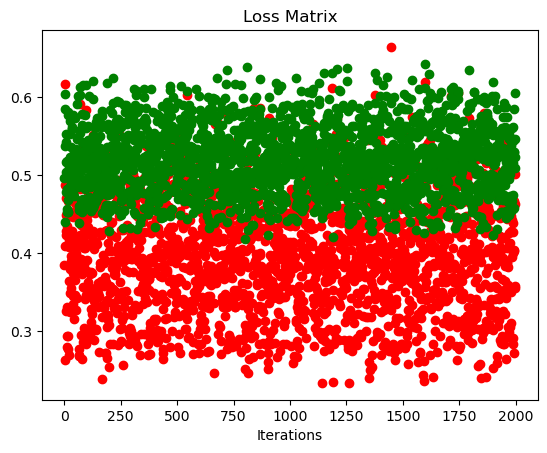

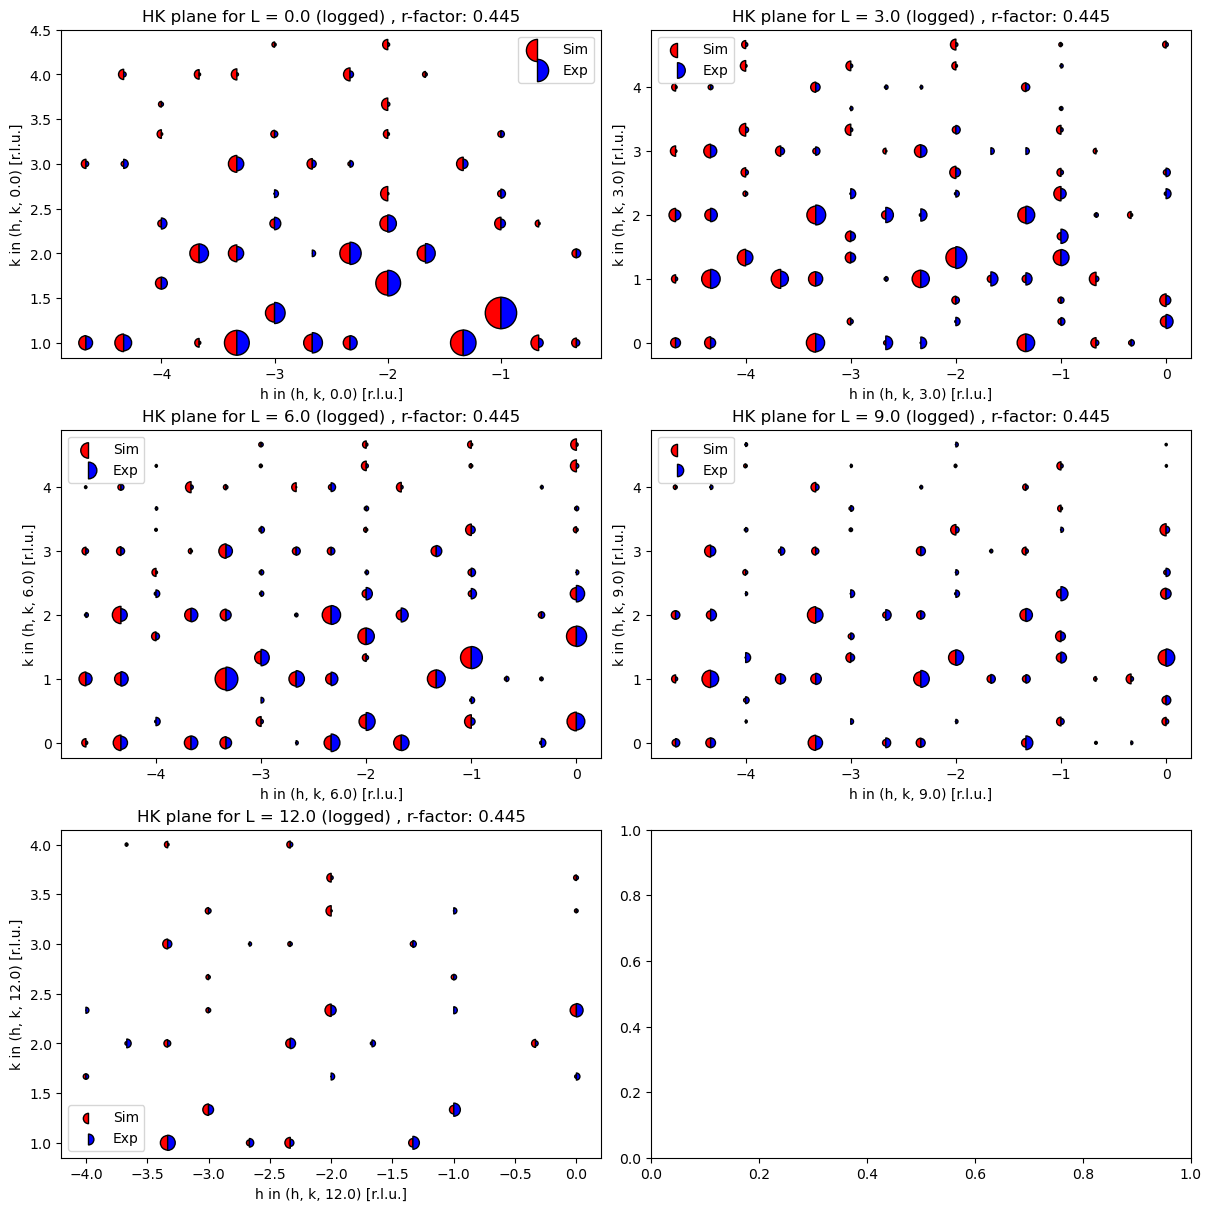

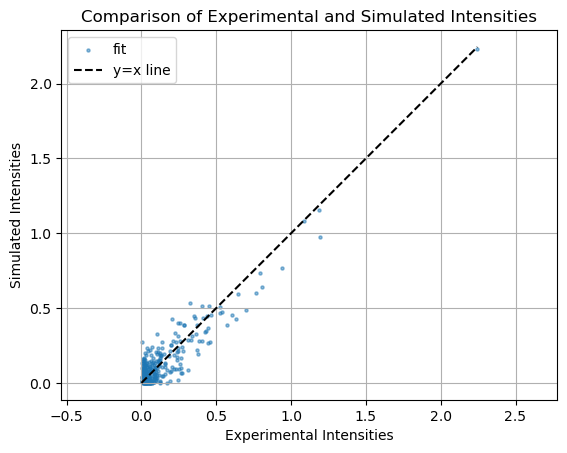

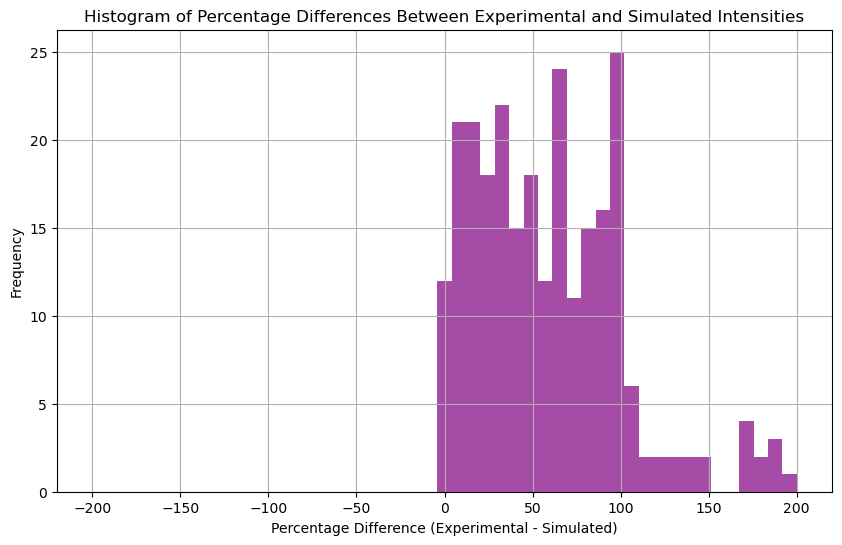

In [16]:
#load file 
number_of_modes = 52
file_name = '20251014_094727_iters2000_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#export hist_matrix as mat file
import scipy.io
scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

# Run1

(52, 500)
Minimum loss index: 217
Minimum loss value: 0.384
Minimum R-factor index: 325


C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.07370323
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.12924124
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.45313758
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.02708197
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : -0.04402121
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.40482664
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : 0.00300924
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : -0.28645745
mode a15 Pmmm[0,1/3,0]DT1(a,0)[Cu1:a:dsp]B2u(a) : -0.00000000
mode a16 Pmmm[1/3,0,0]SM1(a,0)[Cu1:a:

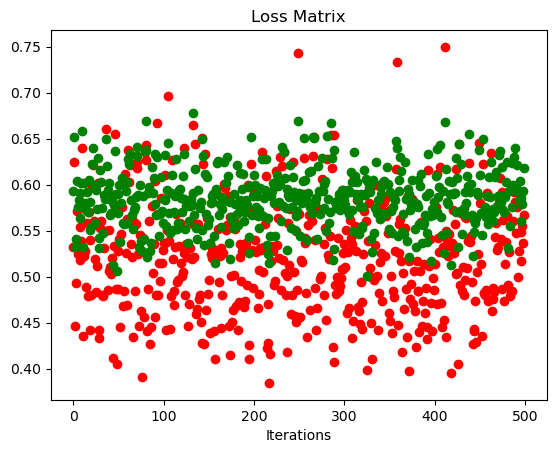

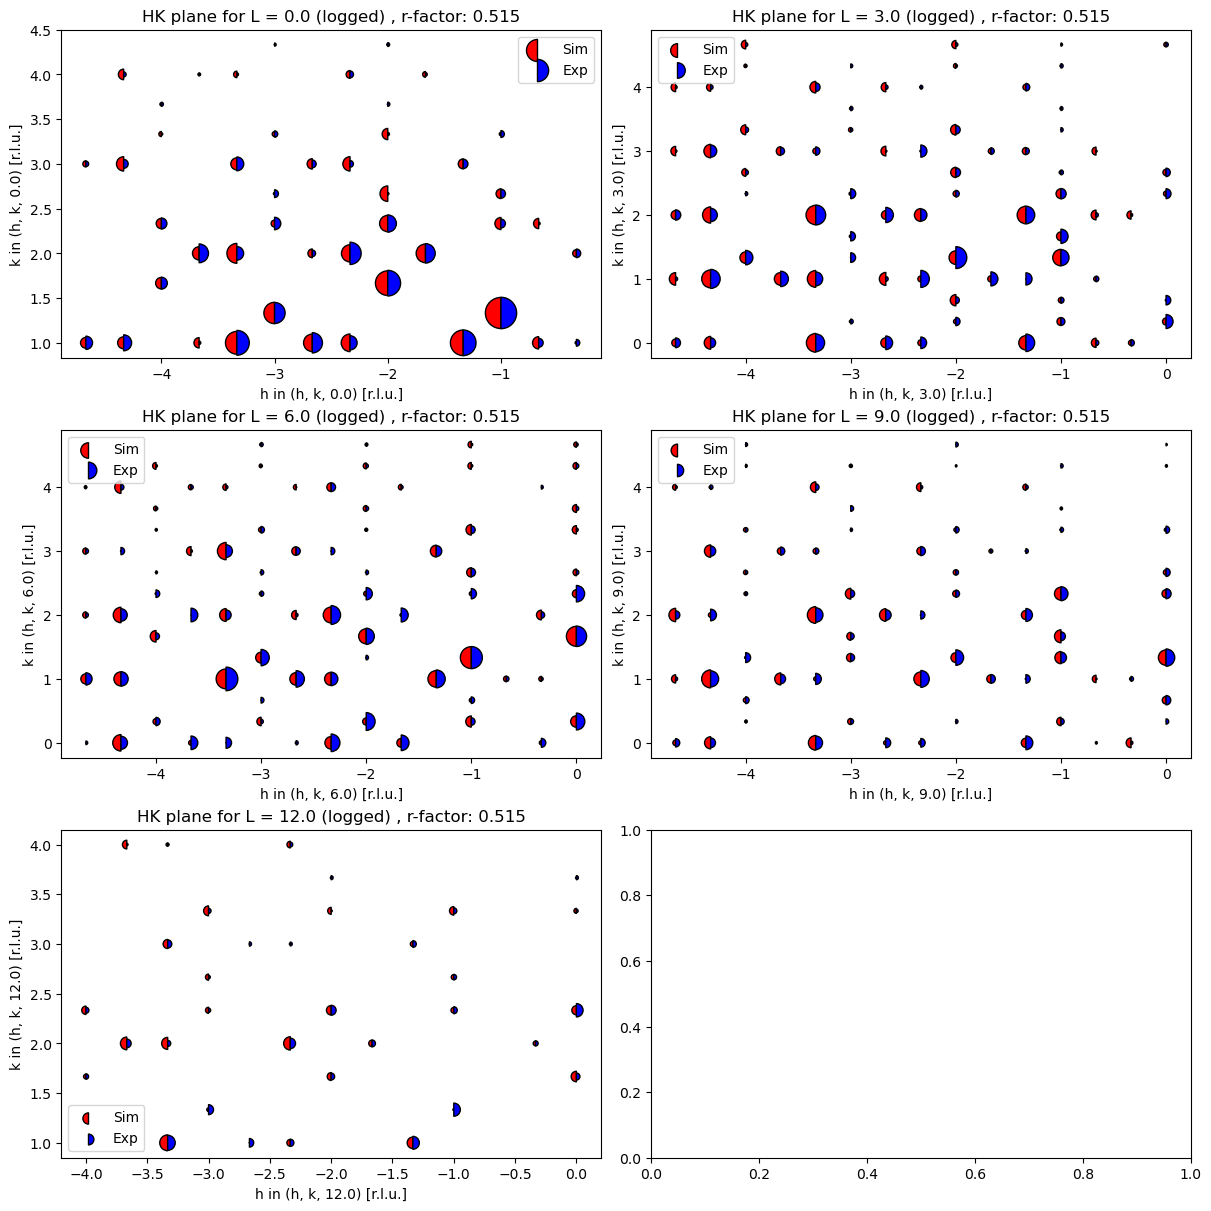

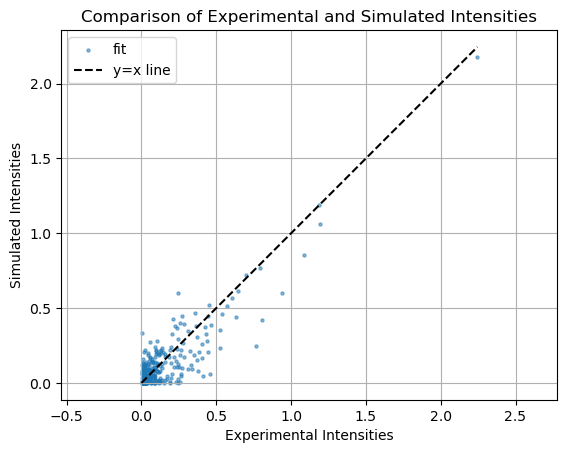

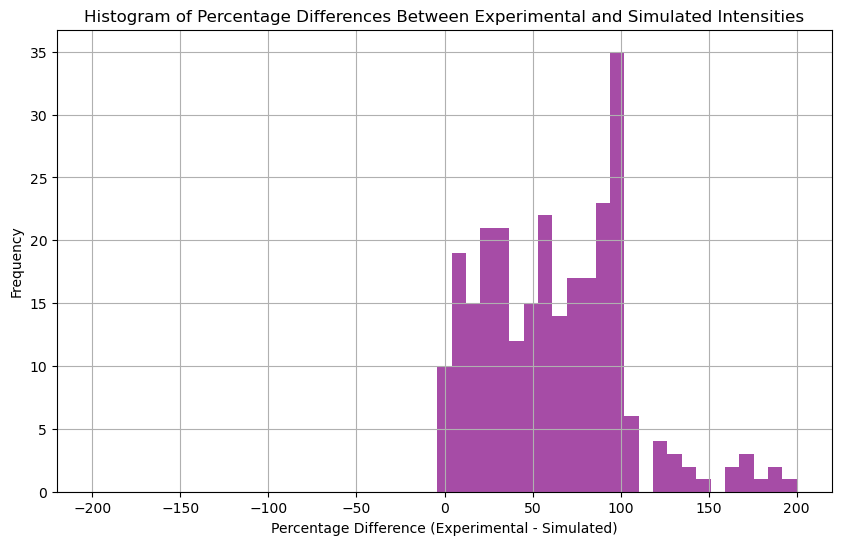

In [6]:
#load file 
number_of_modes = 52
file_name = 'run_1_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

# include mode 3 back in

(52, 500)
Minimum loss index: 95
Minimum loss value: 0.337
Minimum R-factor index: 95
Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : -0.00198802
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : -0.15513426
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.01507027
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.49828693
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : 0.04874209
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : 0.00811227
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.44382122
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : 0.51782799
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : -0.29841602
mode a15 Pmmm

C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


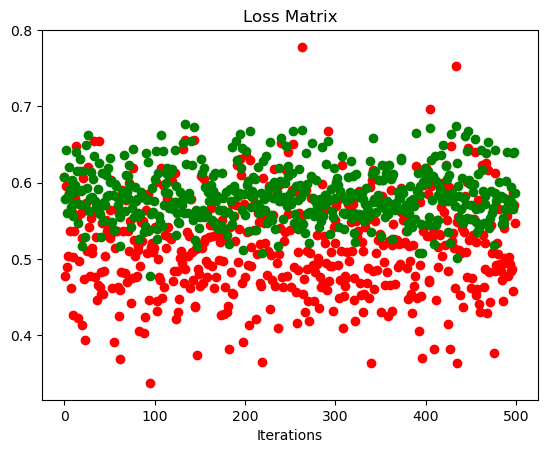

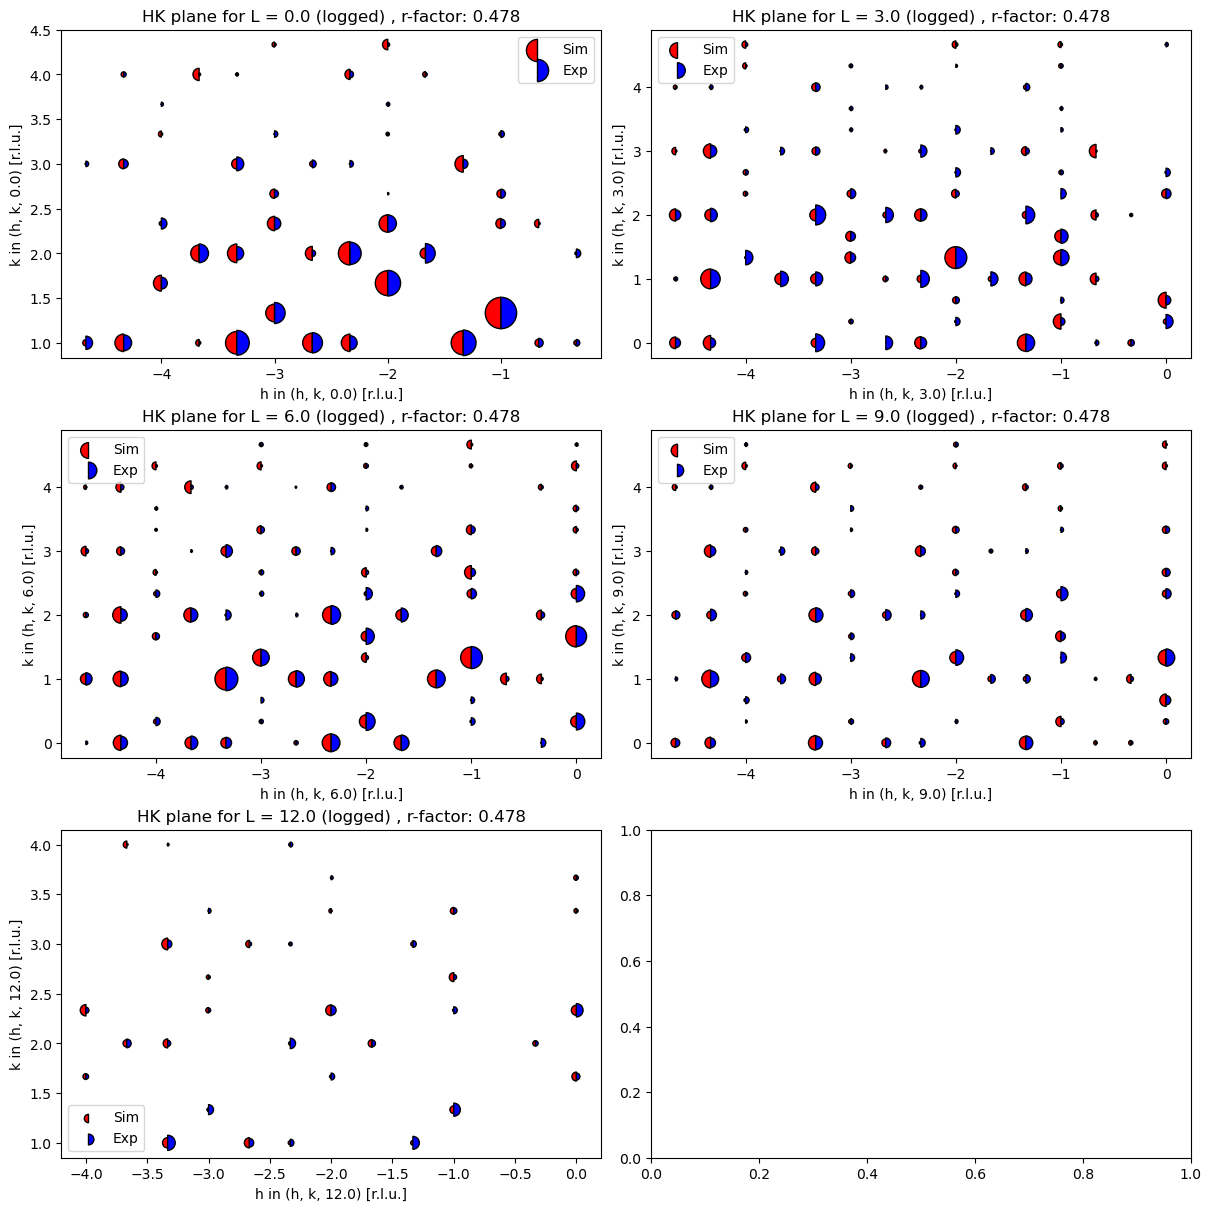

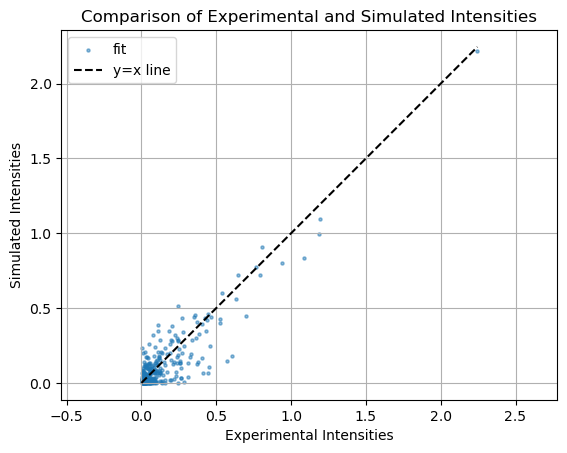

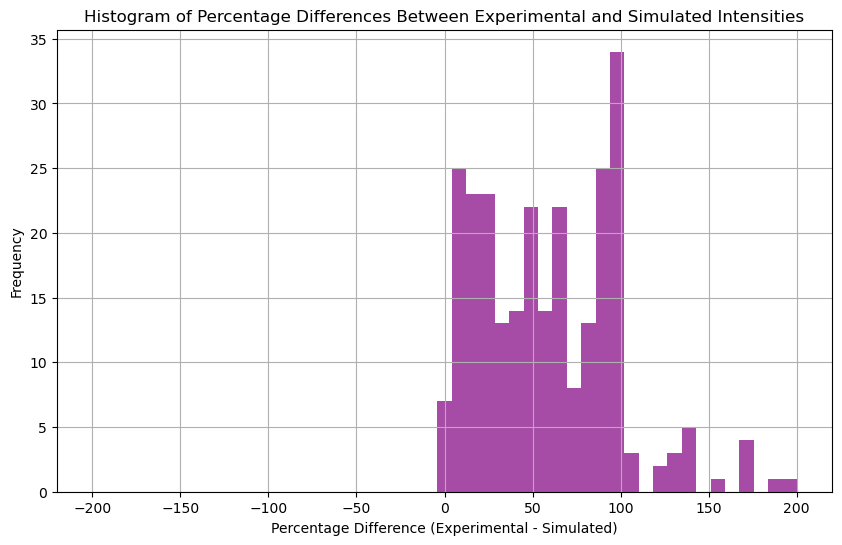

In [7]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_3_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

# run 1 incl mode 4

(52, 500)
Minimum loss index: 29
Minimum loss value: 0.306
Minimum R-factor index: 334


C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : -0.16171773
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : -0.16948166
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.05071630
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.38422781
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : 0.00880474
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : 0.06759903
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.31917894
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.25649792
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : -0.31212306
mode a15 Pmmm[0,1/3,0]DT1(a,0)[Cu1:a:dsp]B2u(a) : -0.00000000
mode a16 Pmmm[1/3,0,0]SM1(a,0)[Cu1:a

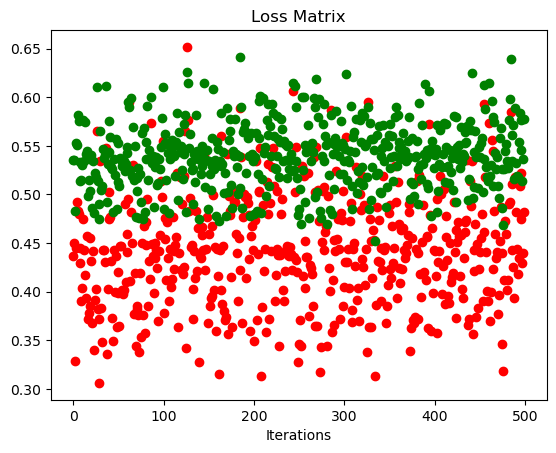

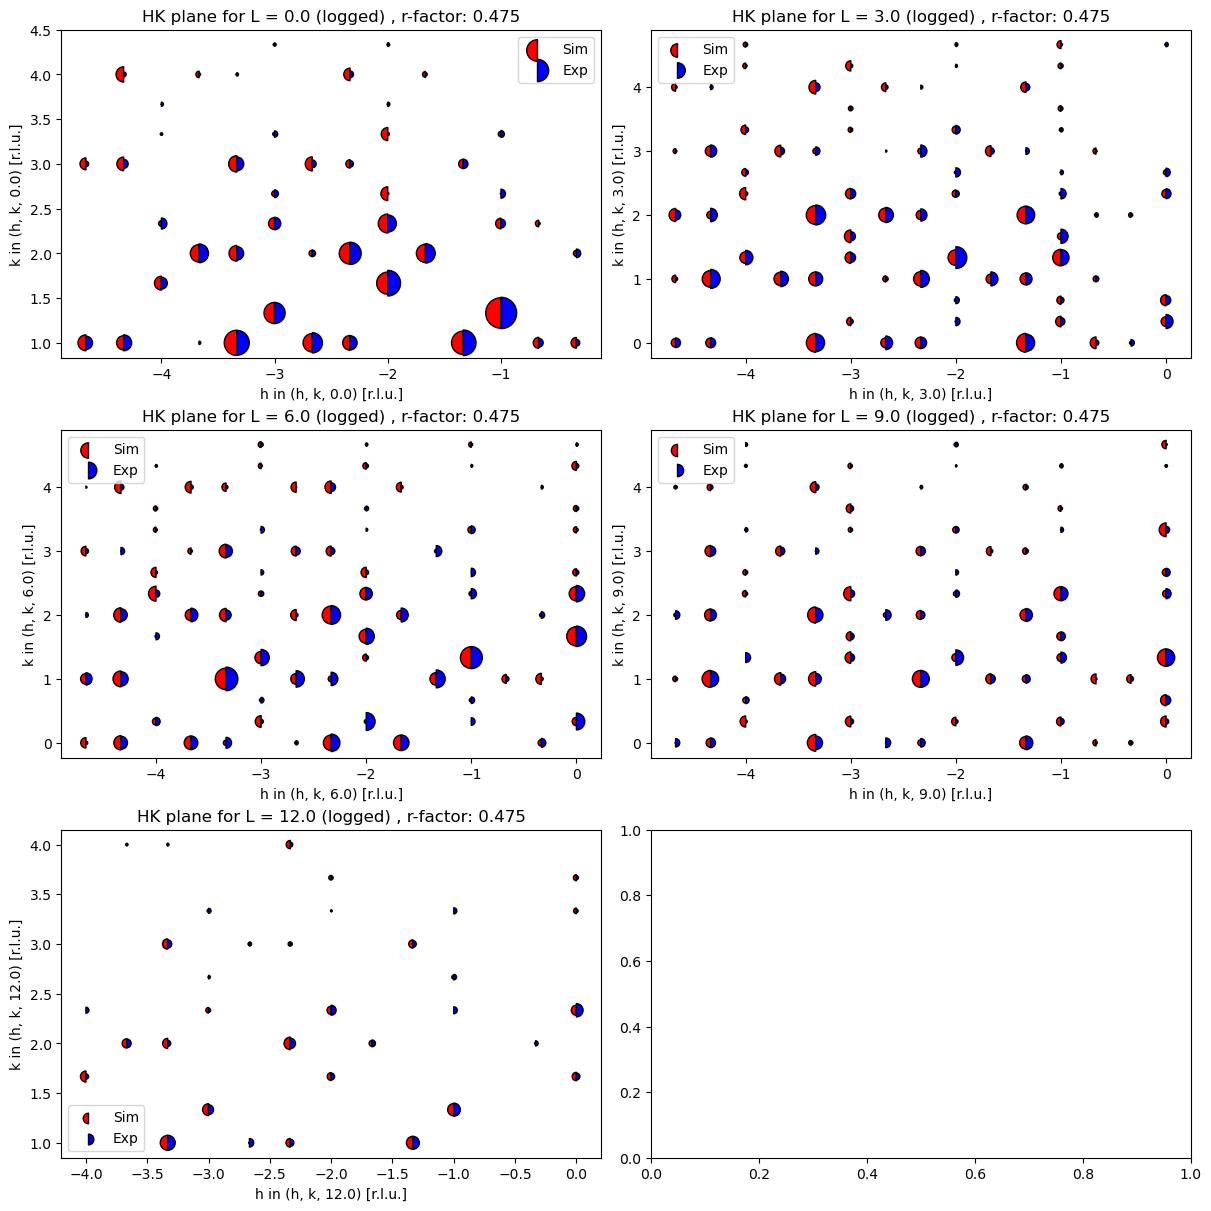

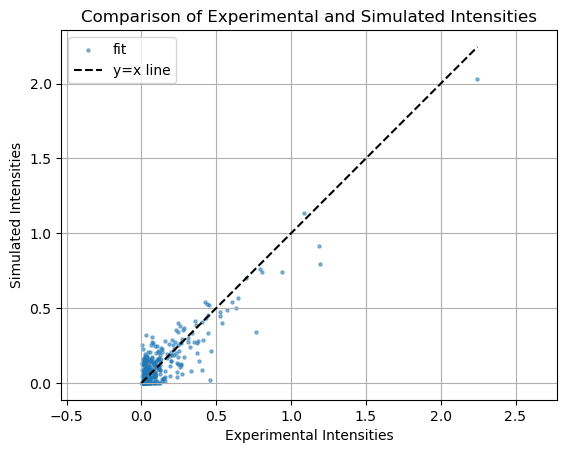

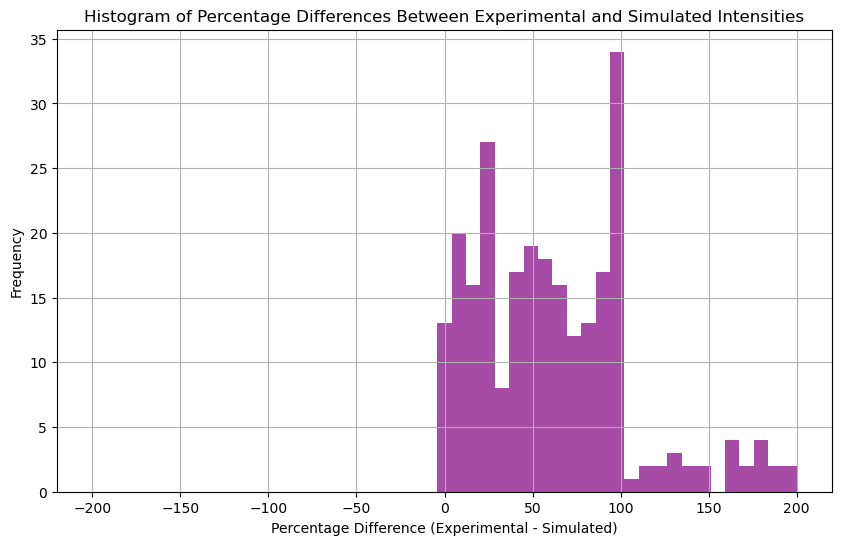

In [8]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_4_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 328
Minimum loss value: 0.349
Minimum R-factor index: 286
Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.17396648
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.13512160
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.16885111
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : 0.21196073
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : 0.23275332
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 1.71147025
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.06940630
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : 0.11939351
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : 0.23254435
mode a15 Pmmm[

C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


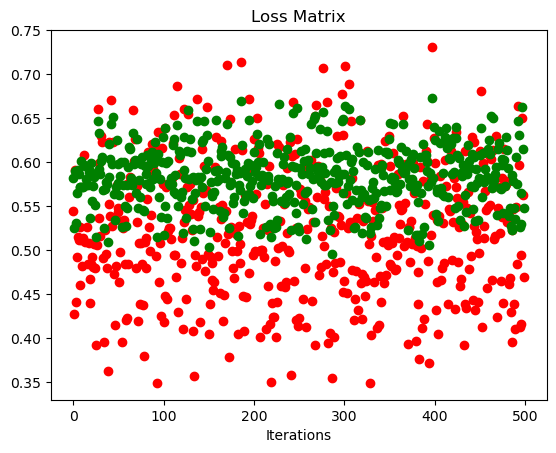

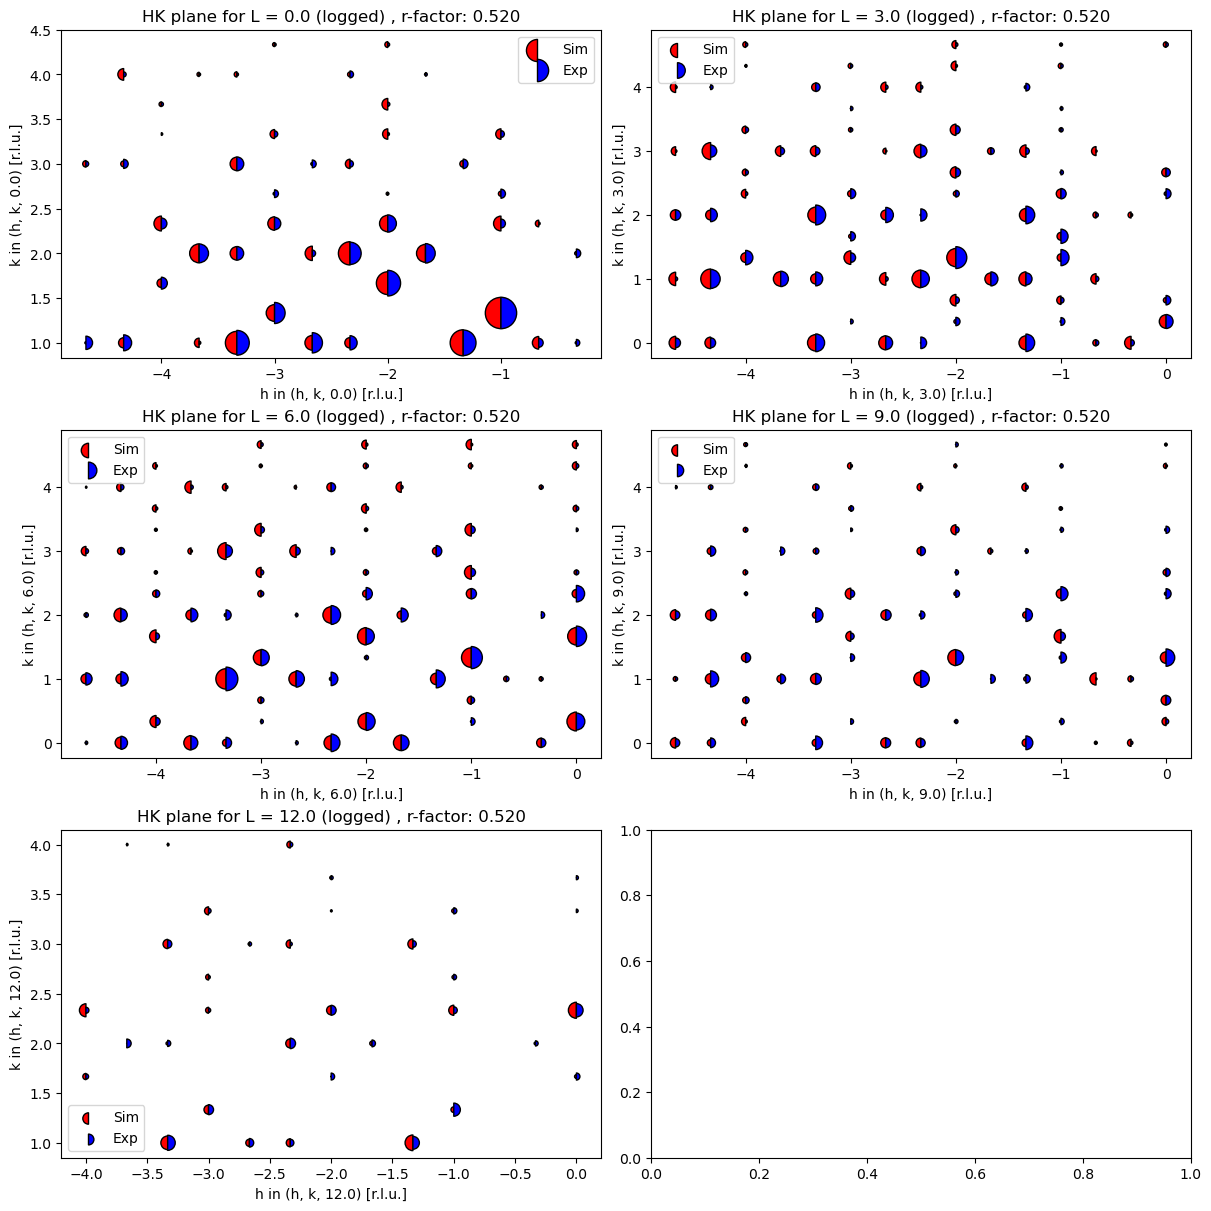

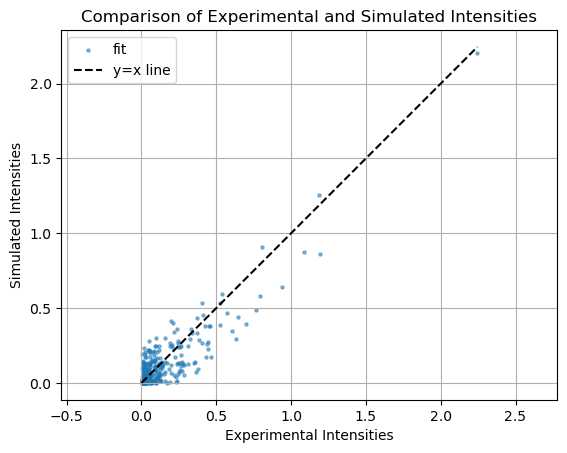

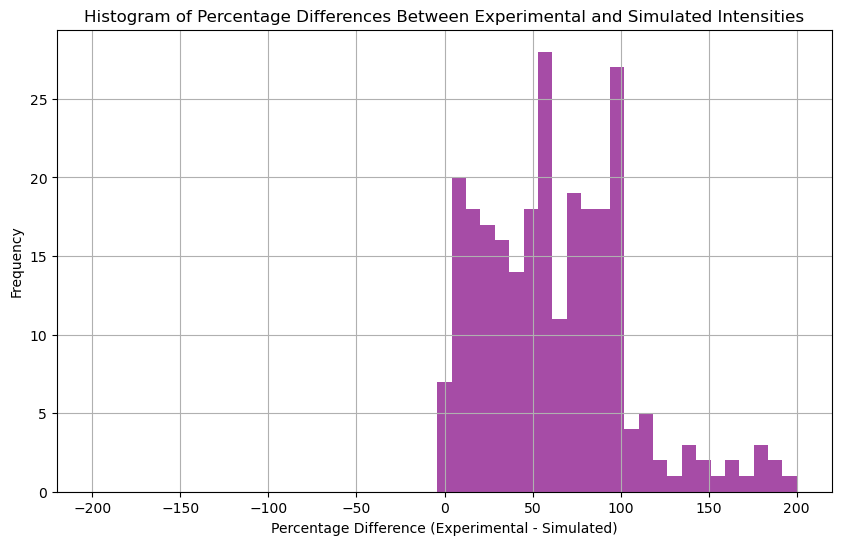

In [9]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_9_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 221
Minimum loss value: 0.351
Minimum R-factor index: 439


C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.00107264
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.14936100
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : -0.30781436
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.03204105
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : 0.09957471
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.41225517
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : 0.00851879
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.08612528
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : -0.22066537
mode a15 Pmmm[0,1/3,0]DT1(a,0)[Cu1:a:dsp]B2u(a) : -0.00000000
mode a16 Pmmm[1/3,0,0]SM1(a,0)[Cu1:a:

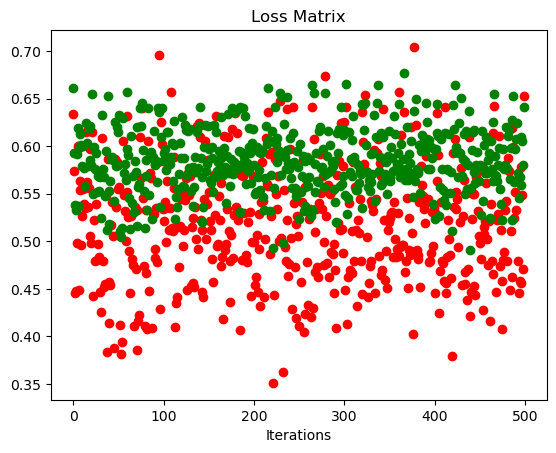

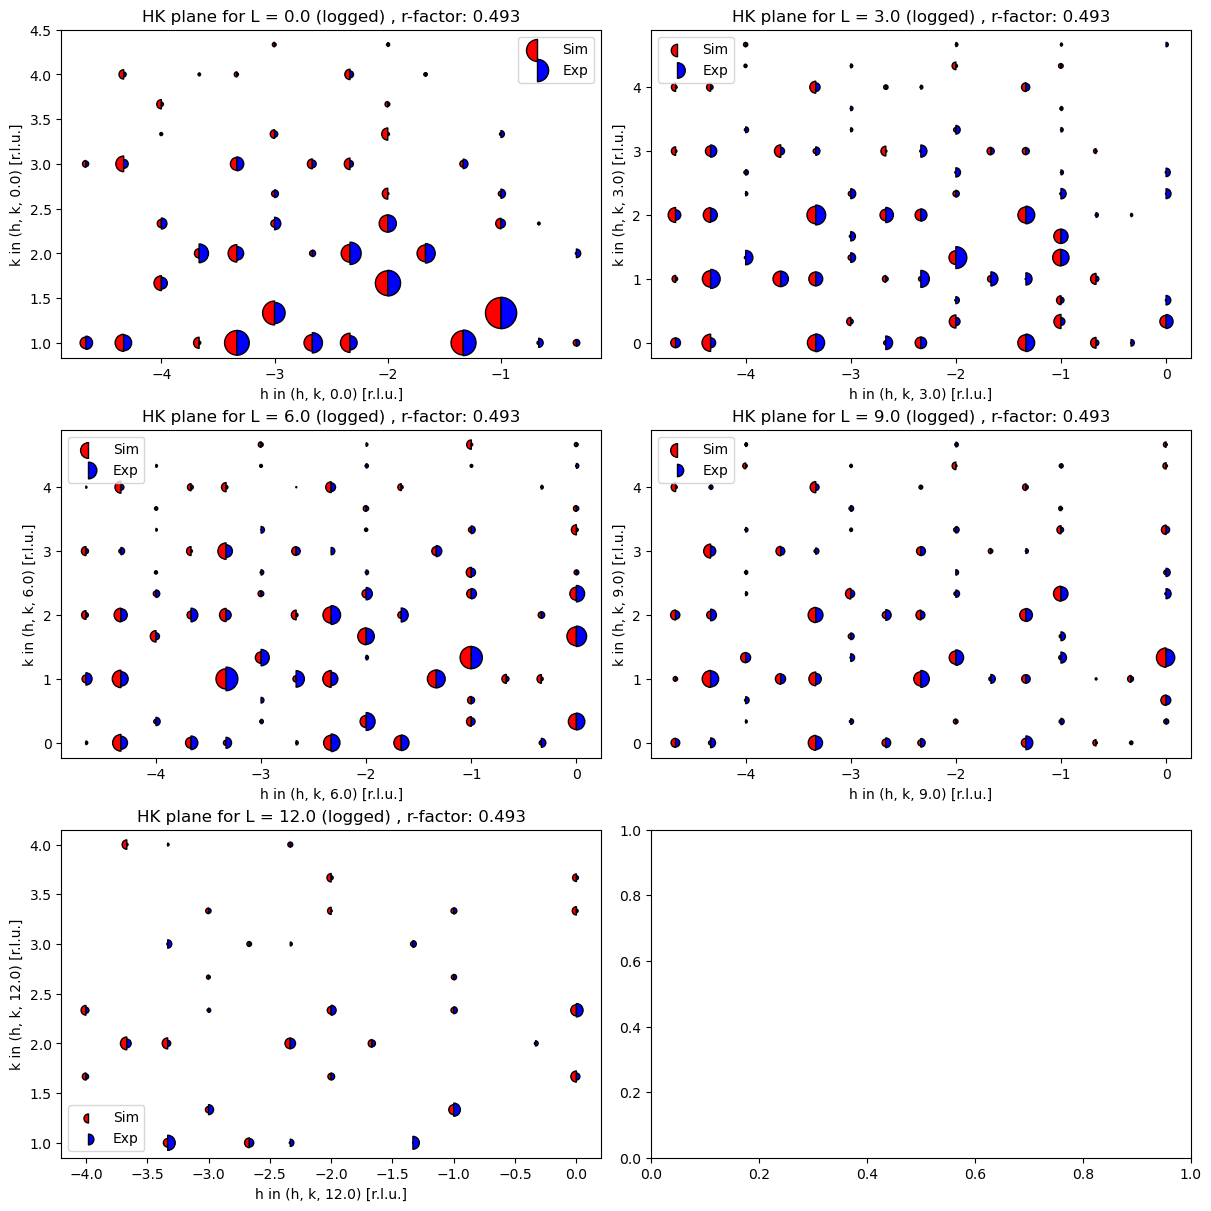

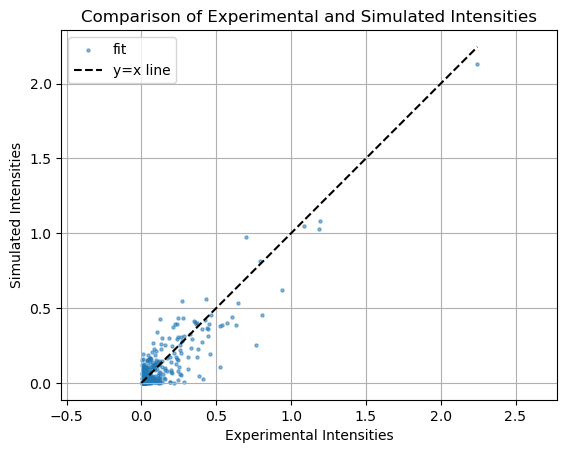

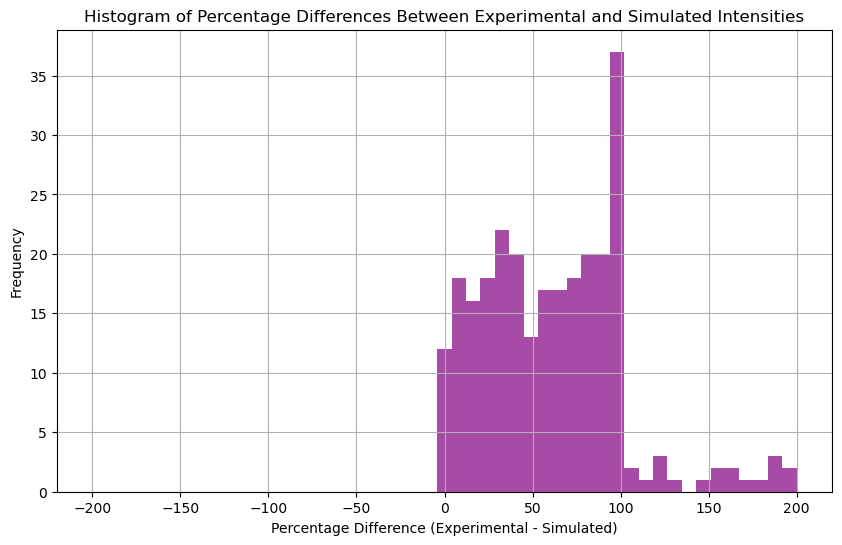

In [10]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_10_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 281
Minimum loss value: 0.371
Minimum R-factor index: 281
Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.13118514
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : -0.07665885
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : -0.30744112
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.05070544
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : -0.16207151
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 2.00178337
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : 0.00011465
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.21835917
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : -0.15632941
mode a15 

C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


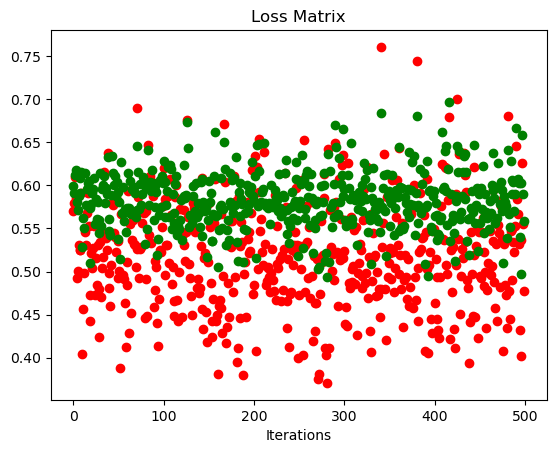

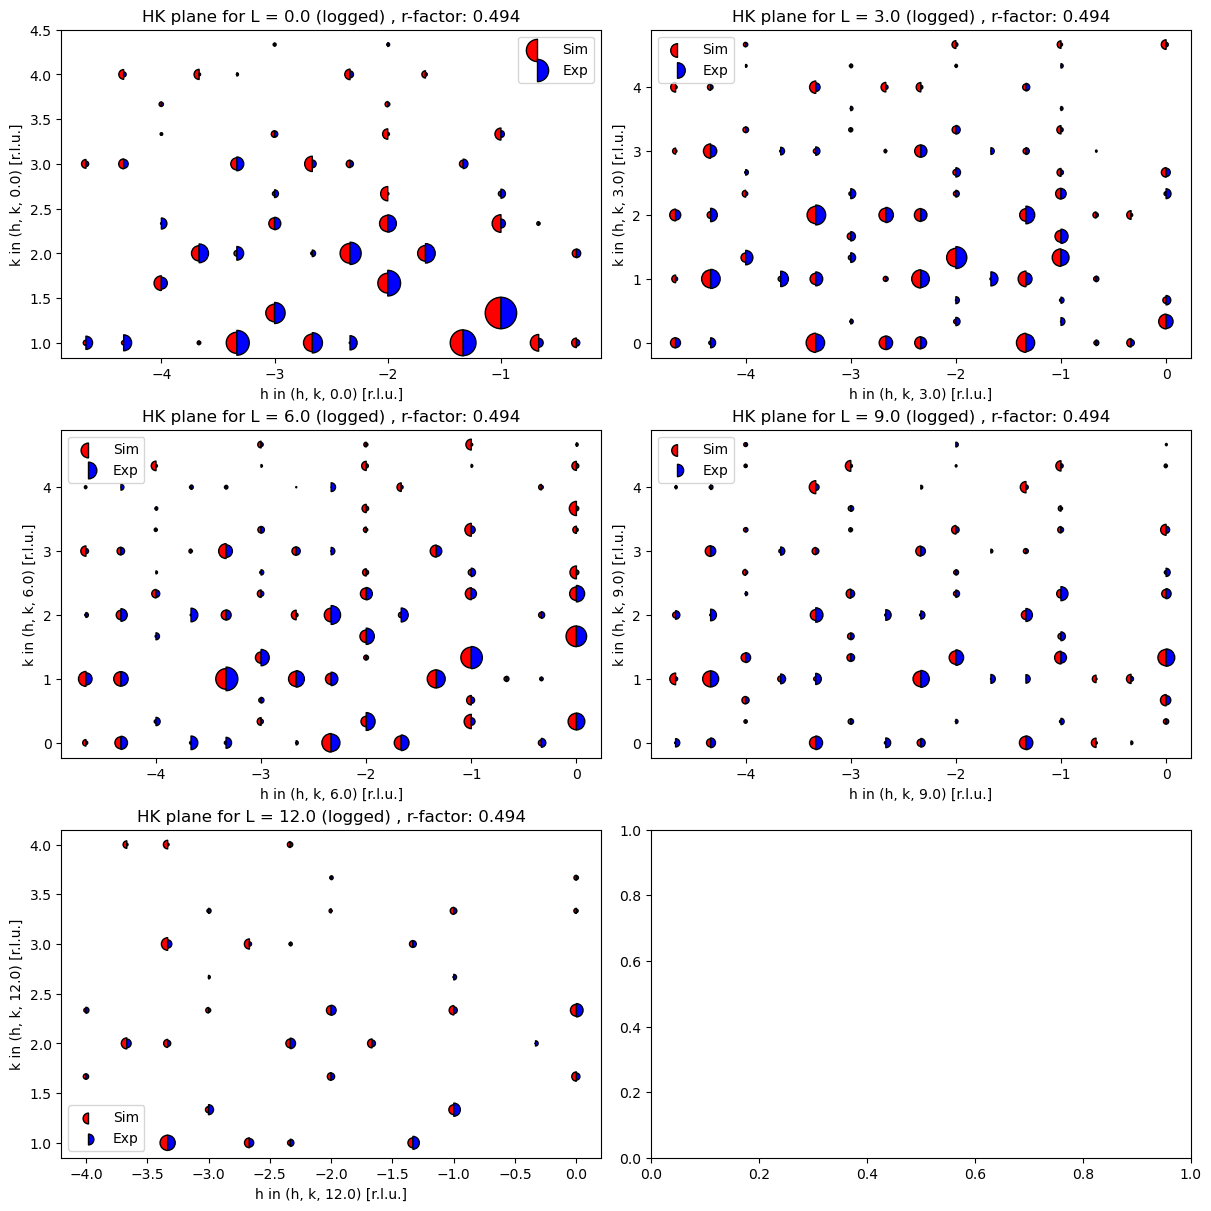

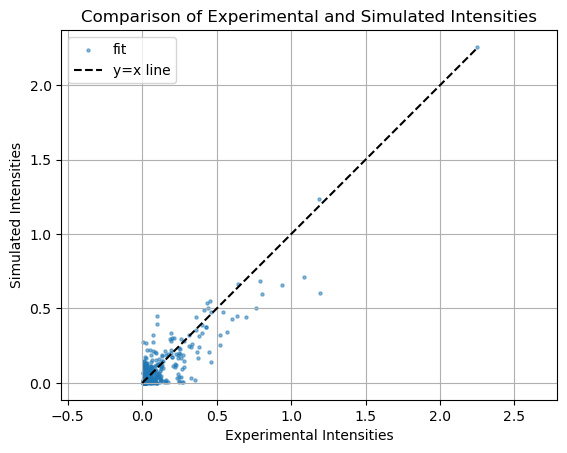

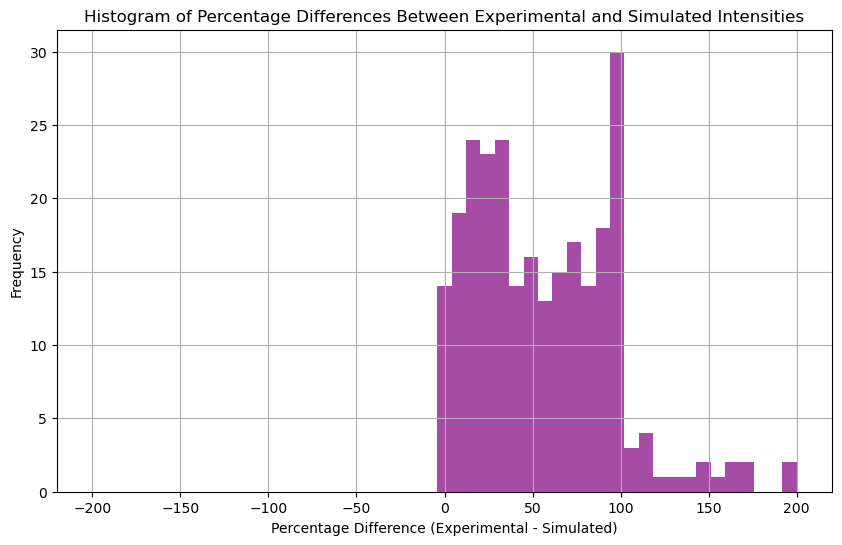

In [11]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_11_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 482
Minimum loss value: 0.288
Minimum R-factor index: 434


C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : -0.12509045
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.17071901
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : -0.20214495
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : 0.05459603
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : 0.10933279
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.15498987
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.03456958
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.29293036
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : 0.30261517
mode a15 Pmmm[0,1/3,0]DT1(a,0)[Cu1:a:dsp]B2u(a) : -0.00000000
mode a16 Pmmm[1/3,0,0]SM1(a,0)[Cu1:a:

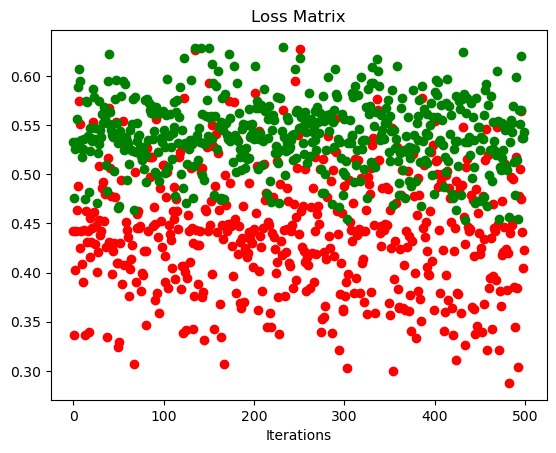

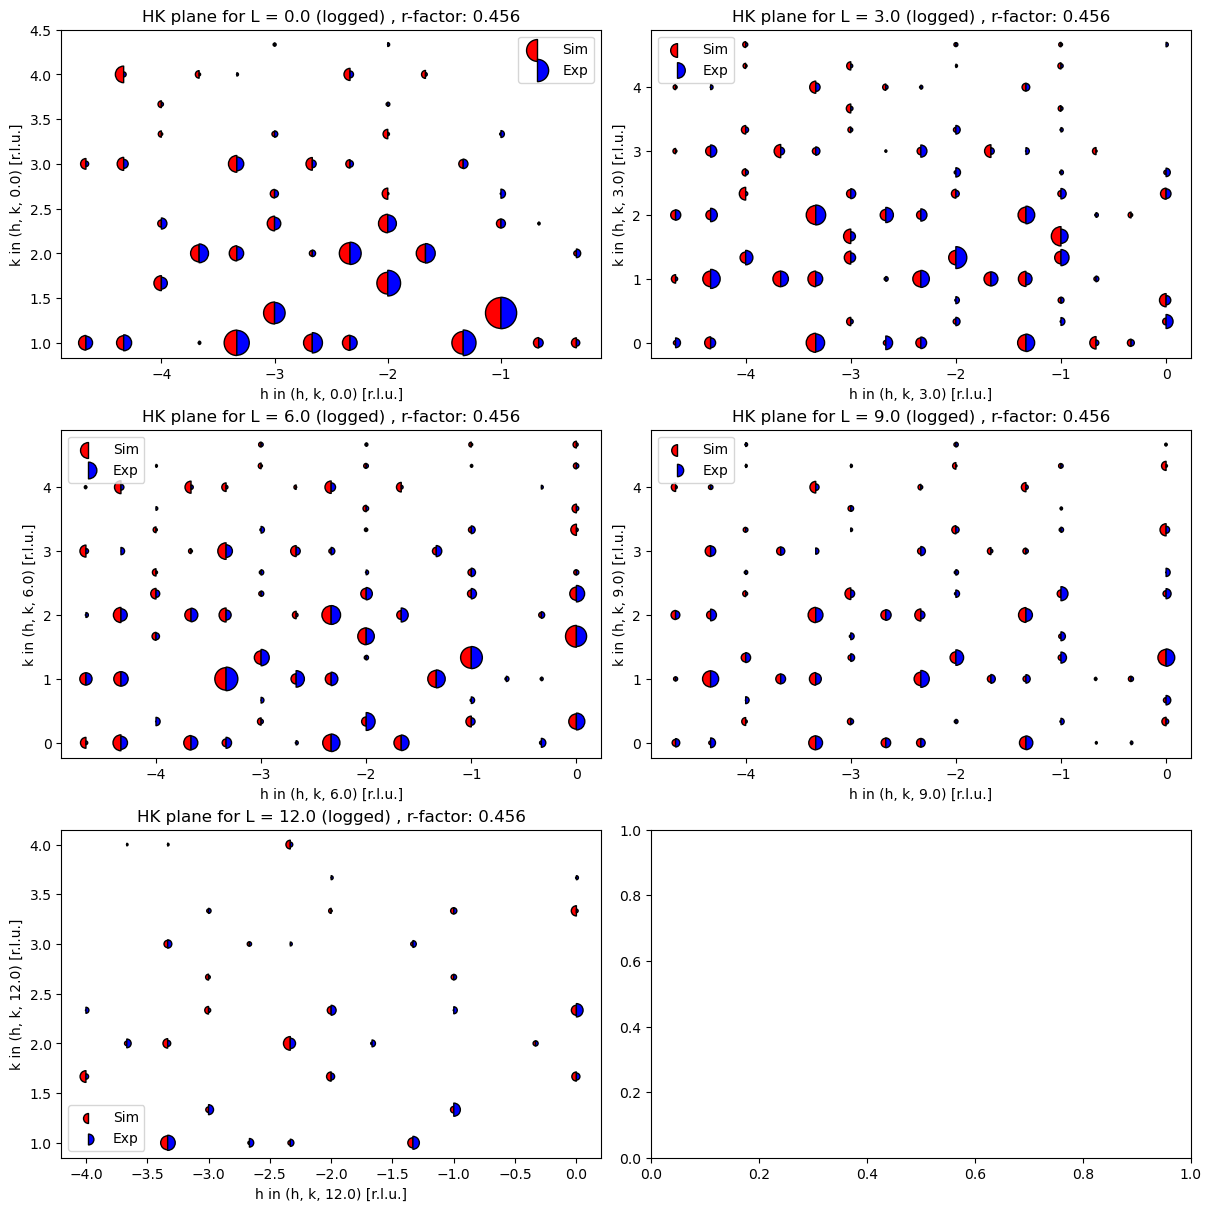

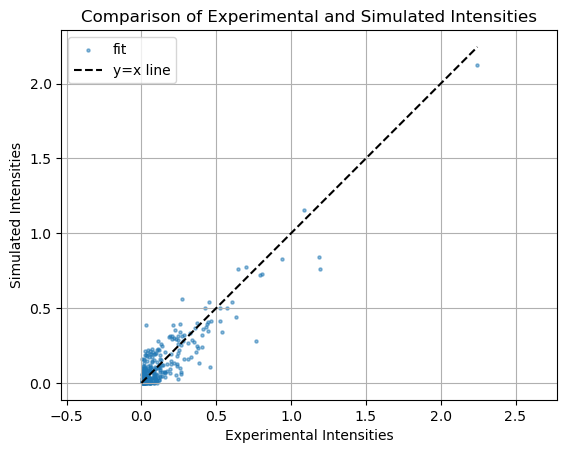

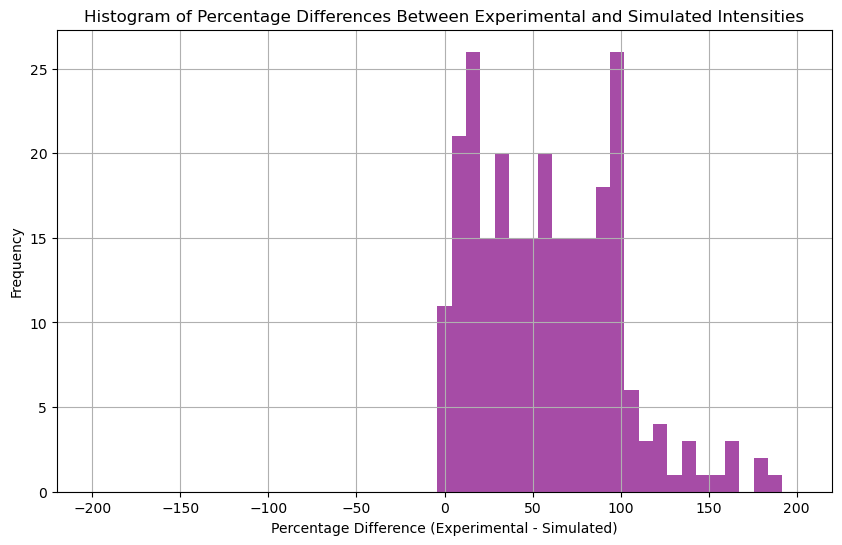

In [18]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_12_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 102
Minimum loss value: 0.354
Minimum R-factor index: 420
Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.11775667
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.06576026
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : -0.28807771
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.03206019
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : -0.17687282
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 1.93626213
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : 0.02005878
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : 0.14497015
mode a15 Pm

C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


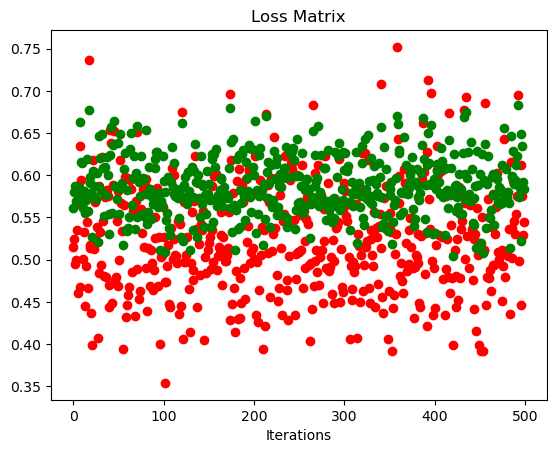

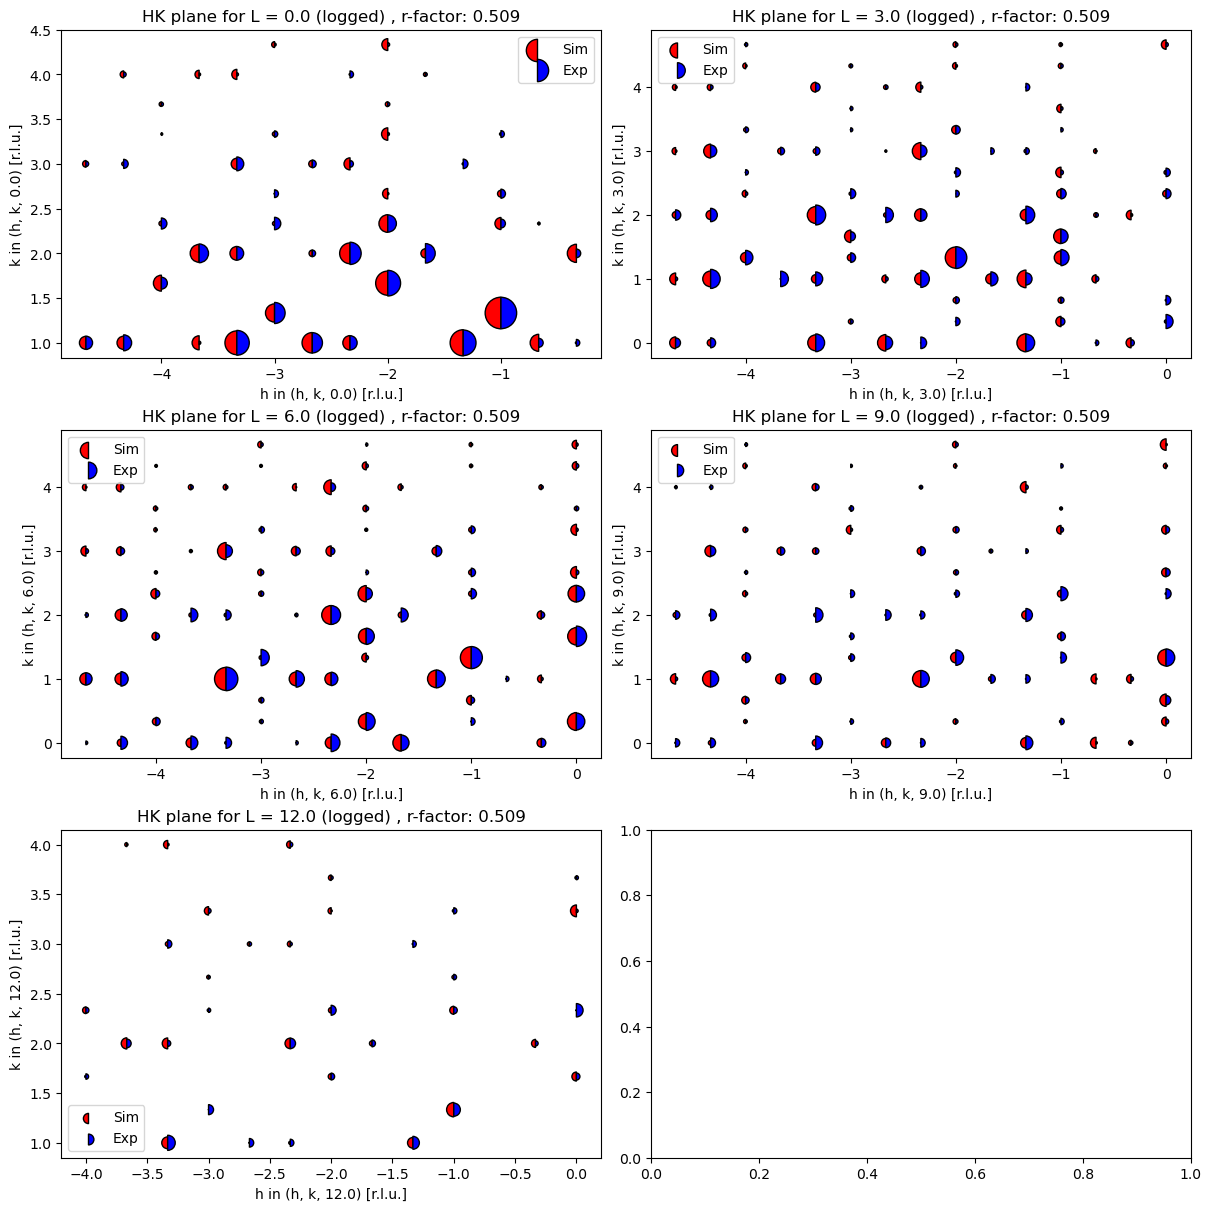

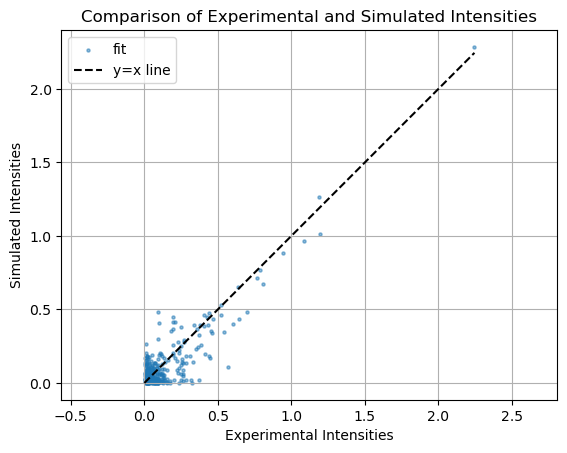

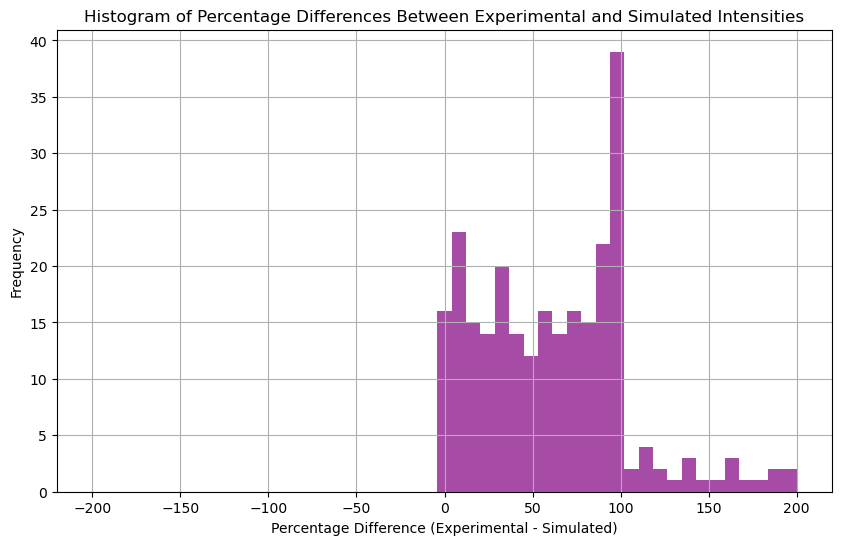

In [13]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_15_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 401
Minimum loss value: 0.375
Minimum R-factor index: 29


C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.00079548
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.15019047
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : -0.47082019
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : 0.06449764
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : 0.01195138
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : -0.03821263
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.32516930
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : -0.21673824
mode a15 Pmmm[0,1/3,0]DT1(a,0)[Cu1:a:dsp]B2u(a) : -0.00000000
mode a16 Pmmm[1/3,0,0]SM1(a,0)[Cu1:a

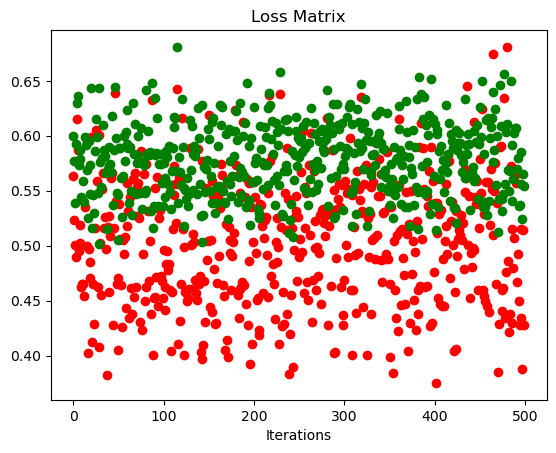

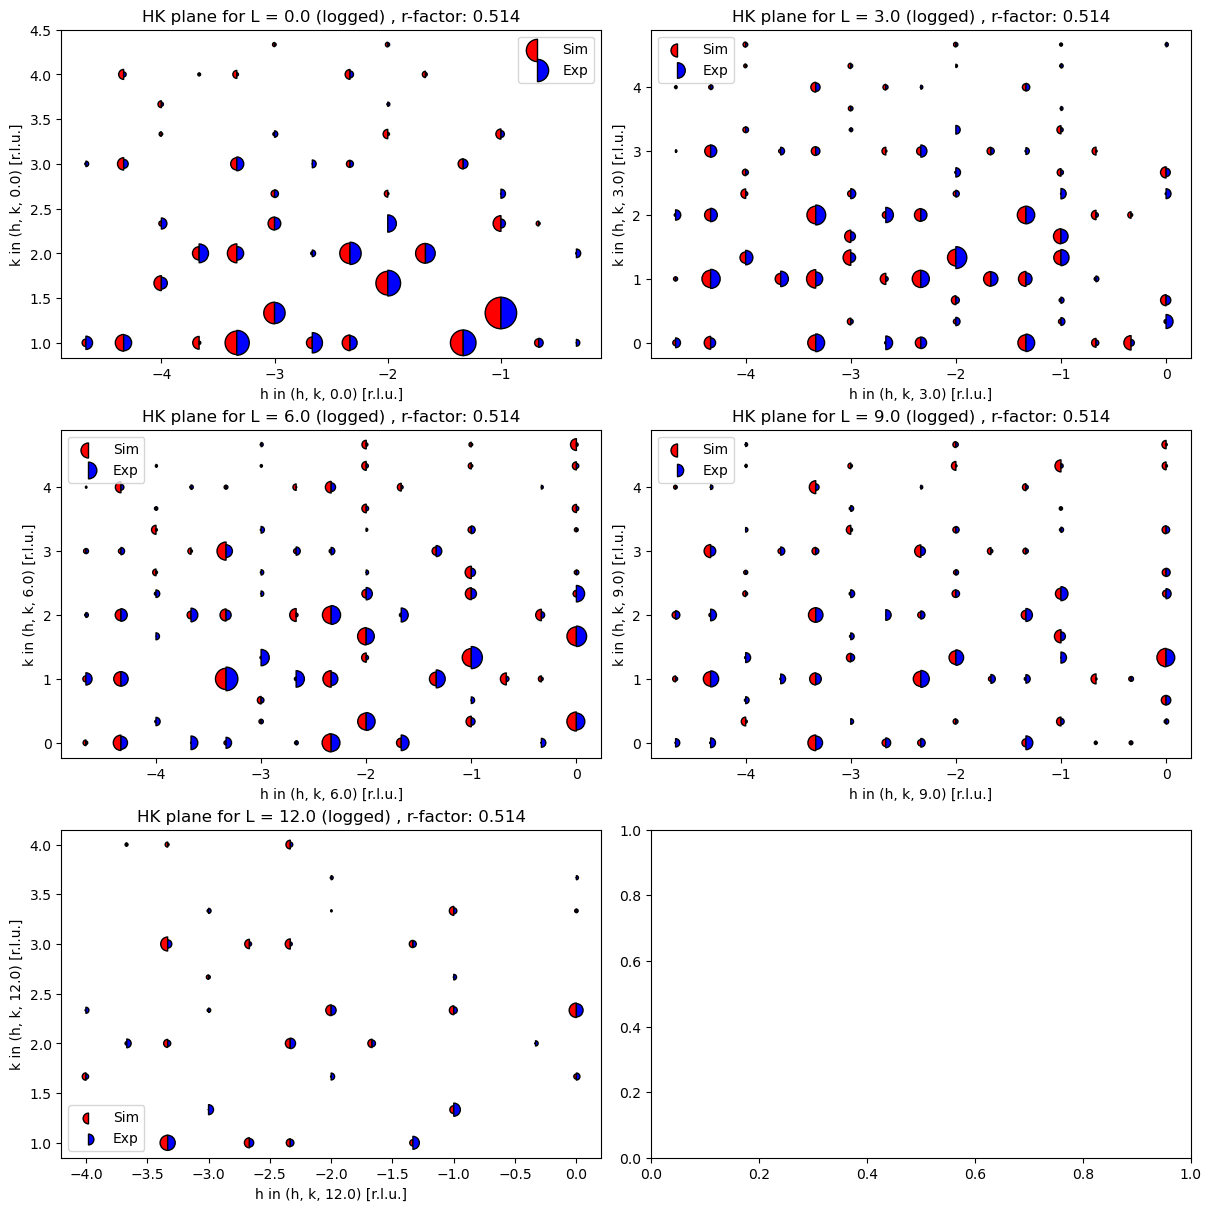

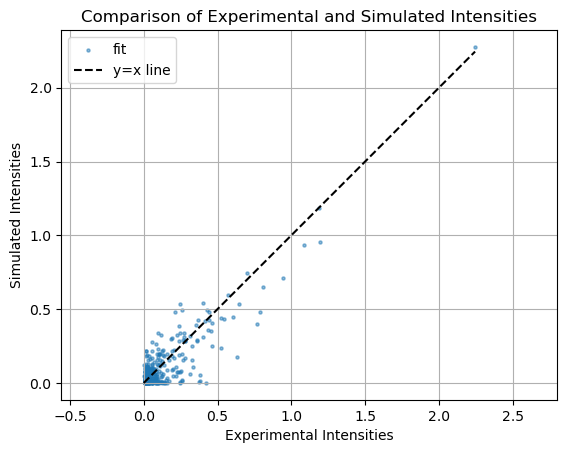

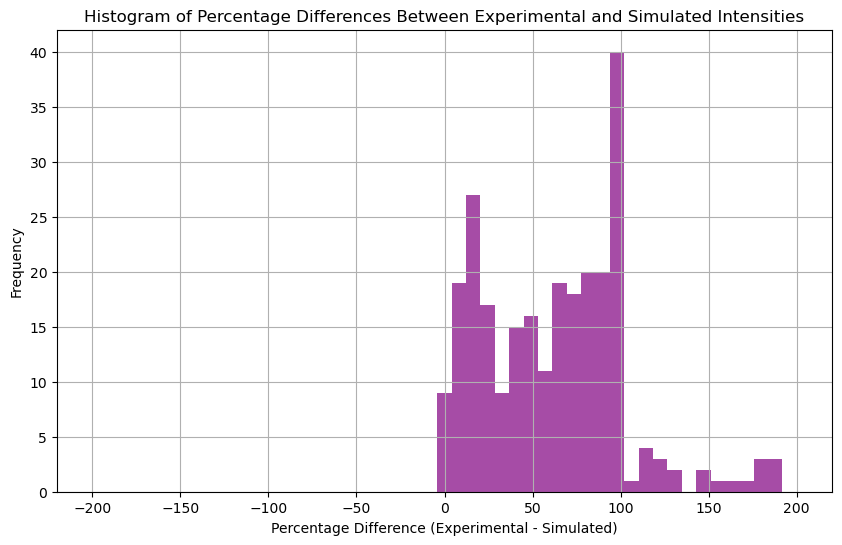

In [14]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_21_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 139
Minimum loss value: 0.347
Minimum R-factor index: 380
Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : -0.03837465
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : -0.13568421
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.40834242
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : 0.04075869
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : -0.06235150
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.47333699
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.05180859
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : 0.17774059
mode a15 P

C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


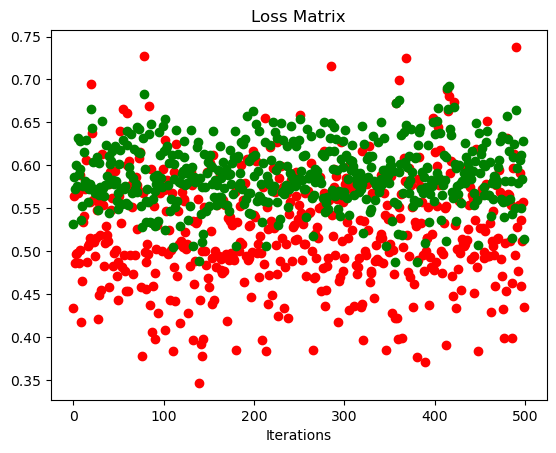

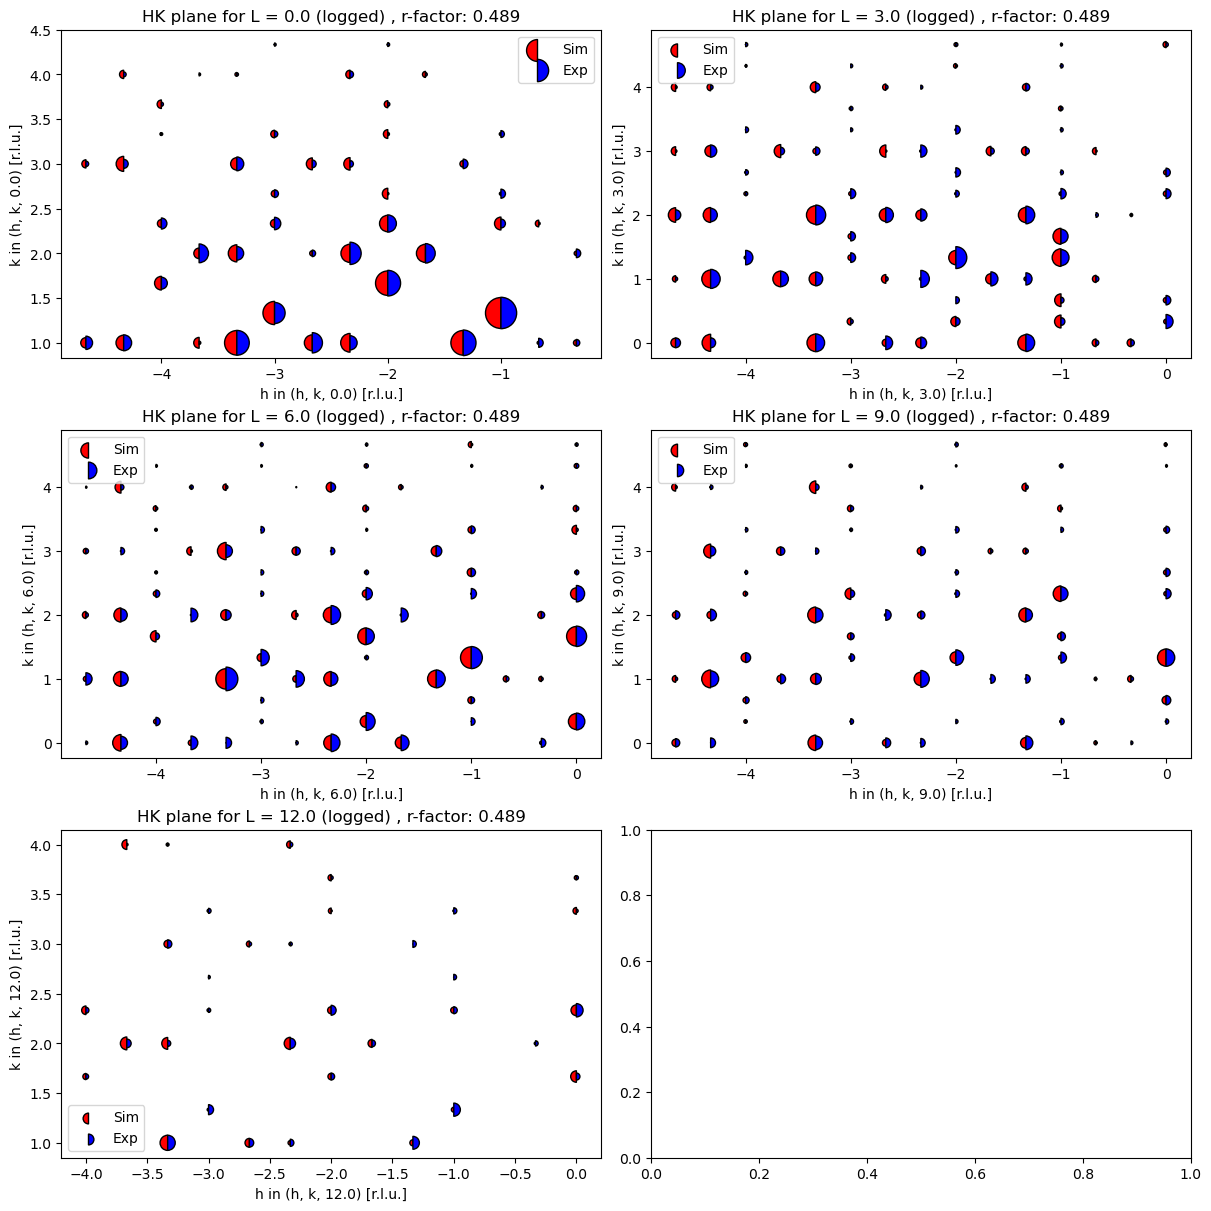

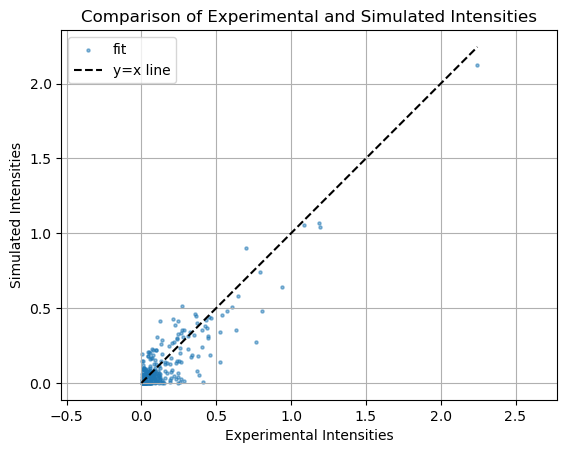

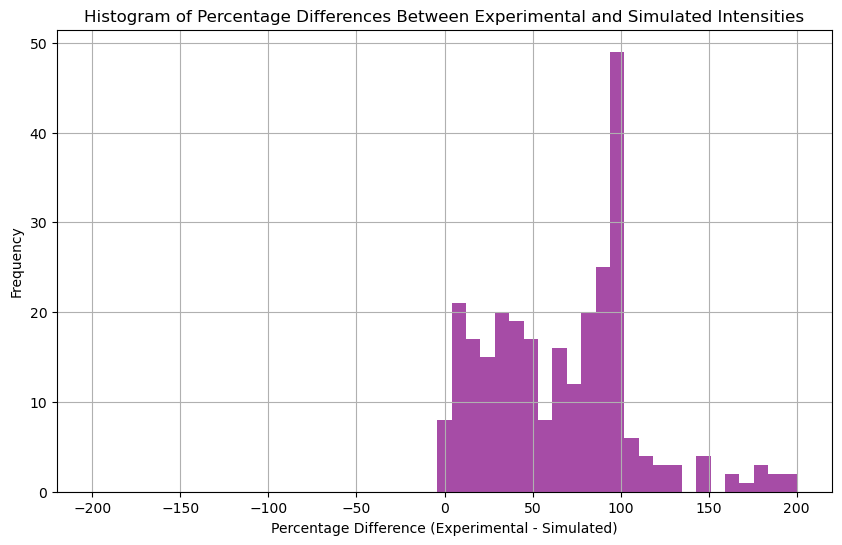

In [15]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_22_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 143
Minimum loss value: 0.333
Minimum R-factor index: 143


C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : -0.00151114
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.16469885
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.42182949
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.06594577
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : -0.07224429
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.53284854
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.09882981
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : 0.23751909
mode a15 Pmmm[0,1/3,0]DT1(a,0)[Cu1:a:dsp]B2u(a) : -0.00000000
mode a16 Pmmm[1/3,0,0]SM1(a,0)[Cu1:a

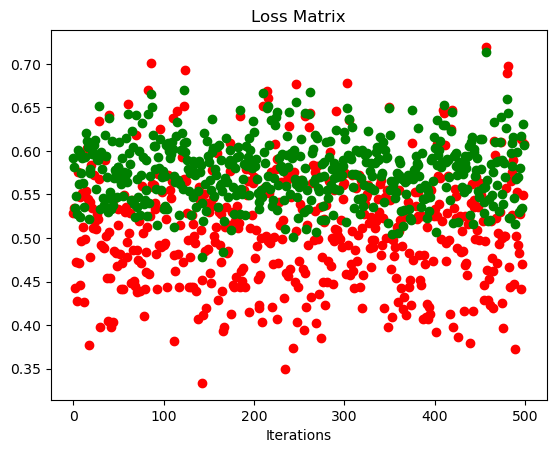

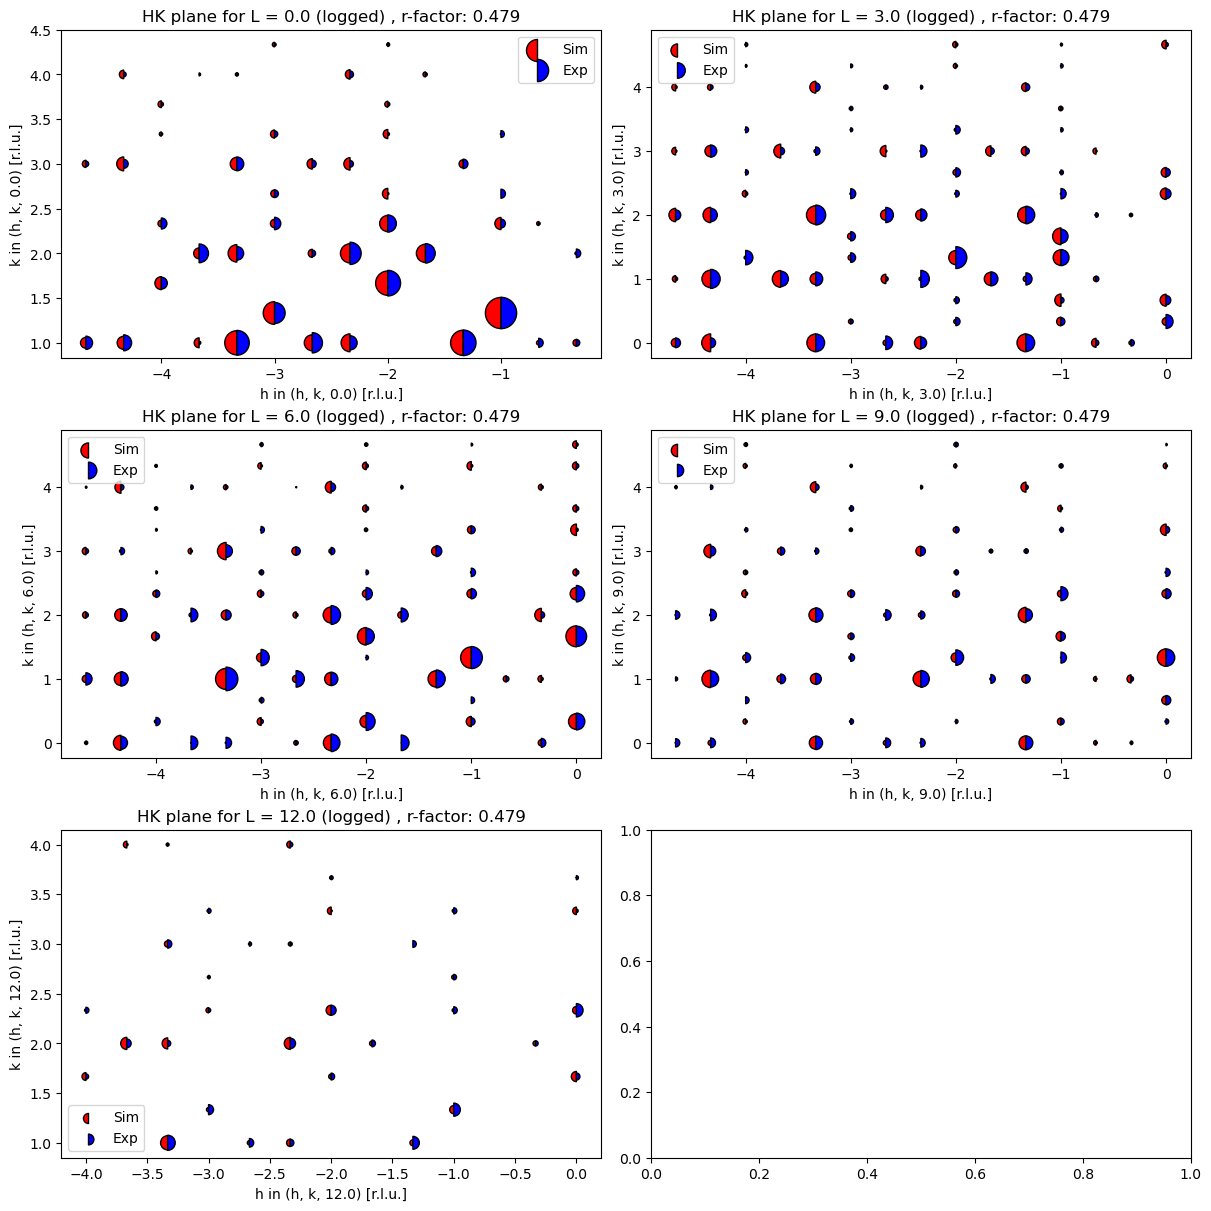

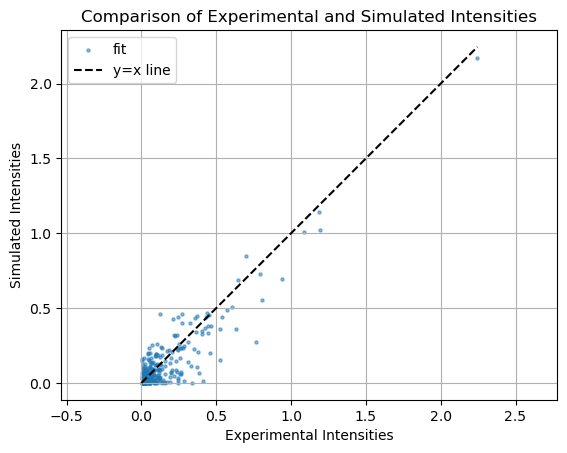

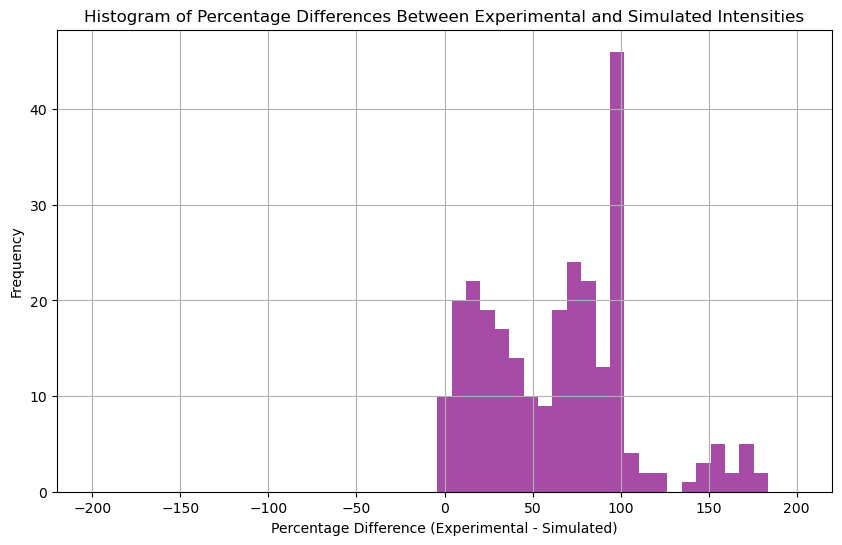

In [16]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_23_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

(52, 500)
Minimum loss index: 53
Minimum loss value: 0.359
Minimum R-factor index: 53
Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.00005195
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.16089226
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.00000000
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : -0.00000000
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.37553895
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.01194537
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : -0.11204905
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.55266696
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : -0.00000000
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : -0.00000000
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : -0.18843336
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : 0.29116488
mode a15 Pmmm

C:\Users\User\AppData\Local\Temp\ipykernel_2888\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


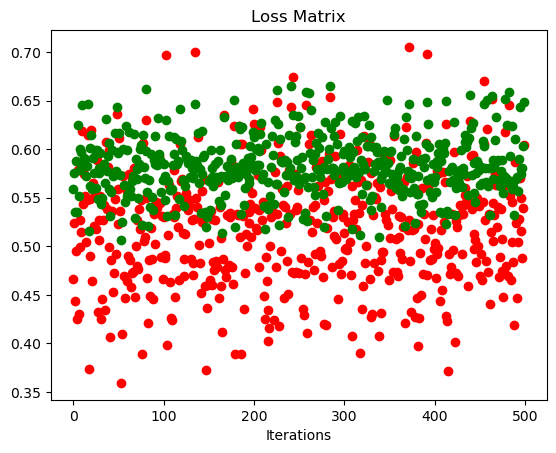

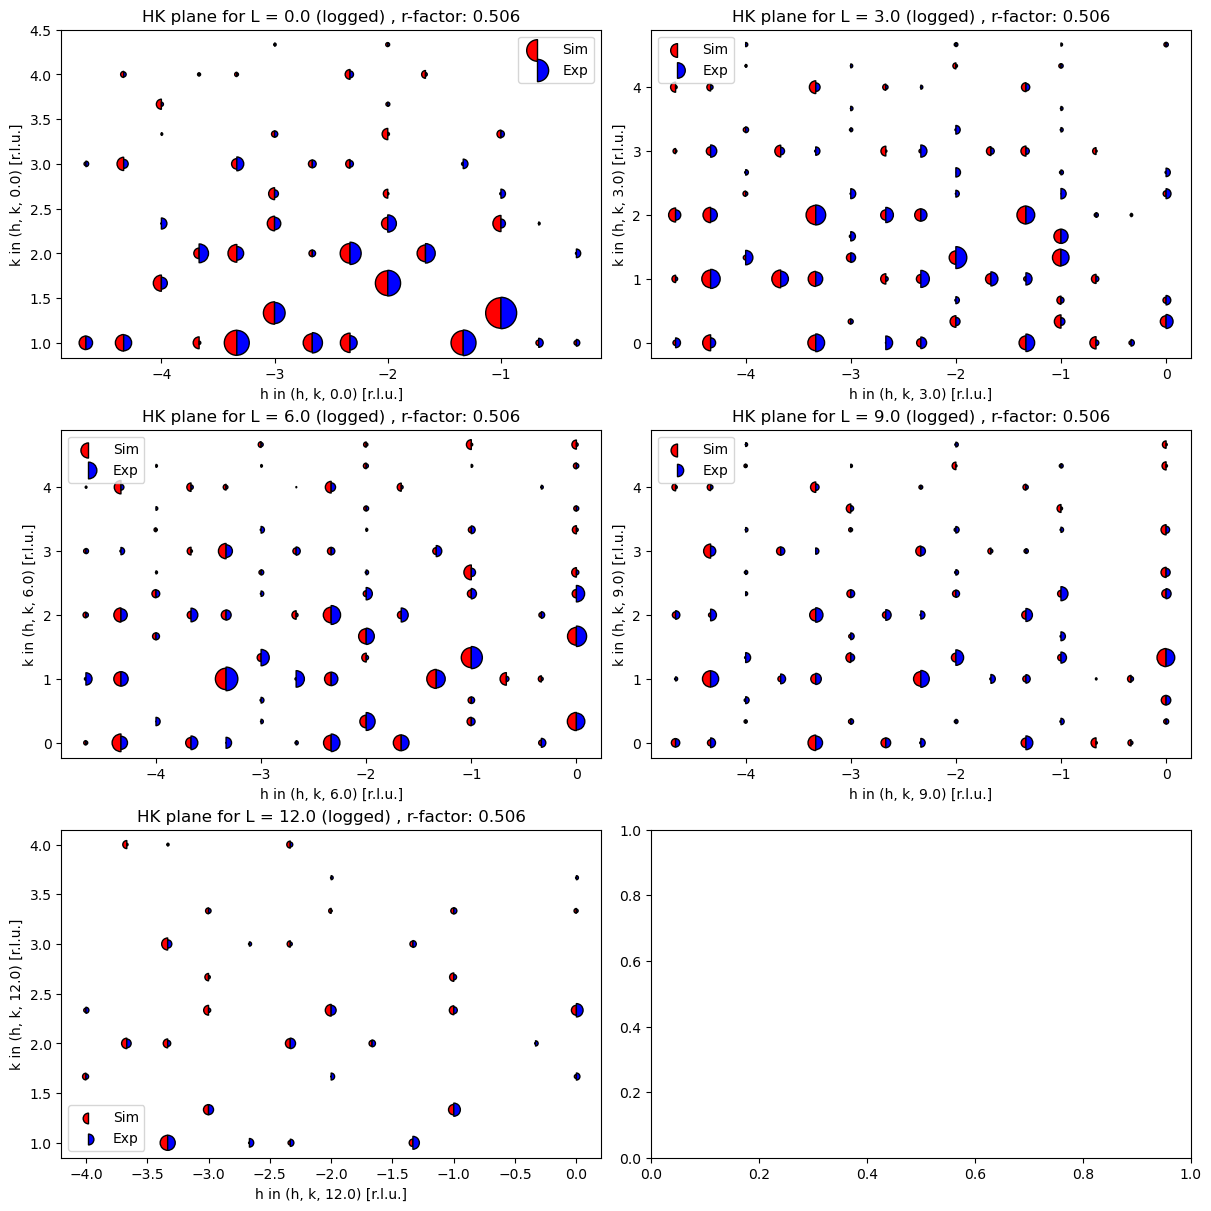

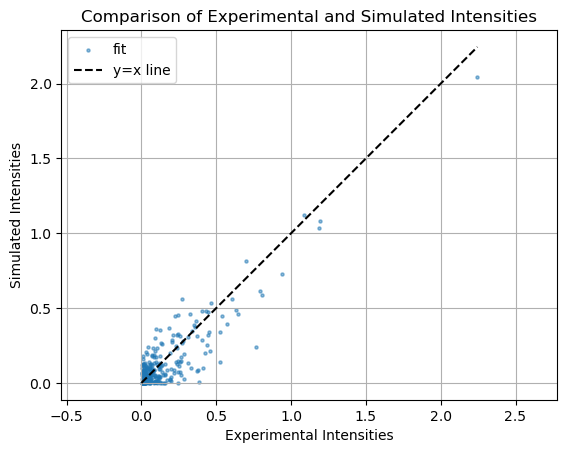

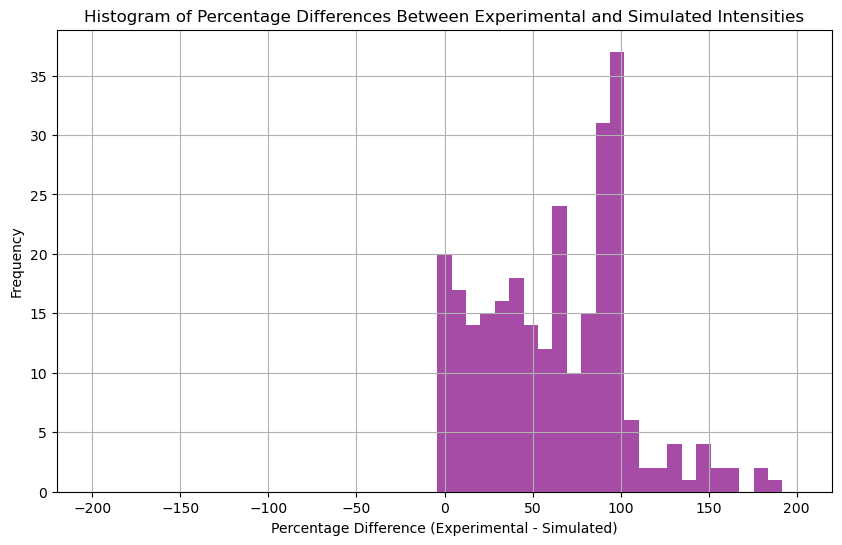

In [17]:
#load file 
number_of_modes = 52
file_name = 'run_1_inc_24_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/run1/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# #export hist_matrix as mat file
# import scipy.io
# scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/histogram_matrix.mat', {'histogram_matrix': hist_matrix})

# run 2

(52, 500)
Minimum loss index: 414
Minimum loss value: 0.275
Minimum R-factor index: 258


C:\Users\User\AppData\Local\Temp\ipykernel_16664\571674095.py:27: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv(path_displacive_modes, delim_whitespace=True, header=None)


Best model parameters:
mode a1 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a) : 0.10363242
mode a2 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a) : 0.16747022
mode a3 Pmmm[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a) : -0.01605648
mode a4 Pmmm[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a) : 0.06732165
mode a5 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]A1(a) : 0.07194413
mode a6 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B2(a) : -0.11375378
mode a7 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Ba1:t:dsp]B1(a) : -0.28565833
mode a8 Pmmm[0,0,0]GM1+(a)[Ba1:t:dsp]A1(a) : 0.38637203
mode a9 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]A1(a) : -0.00000000
mode a10 Pmmm[0,1/3,0]DT1(a,0)[Ba1:t:dsp]B2(a) : 0.01633204
mode a11 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]A1(a) : 0.00504881
mode a12 Pmmm[1/3,0,0]SM1(a,0)[Ba1:t:dsp]B1(a) : 0.01767232
mode a13 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B3u(a) : 0.24693345
mode a14 Pmmm[1/3,1/3,0]V1(a,0;a,0)[Cu1:a:dsp]B2u(a) : 0.07941758
mode a15 Pmmm[0,1/3,0]DT1(a,0)[Cu1:a:dsp]B2u(a) : -0.00000000
mode a16 Pmmm[1/3,0,0]SM1(a,0)[Cu1:a:dsp]B

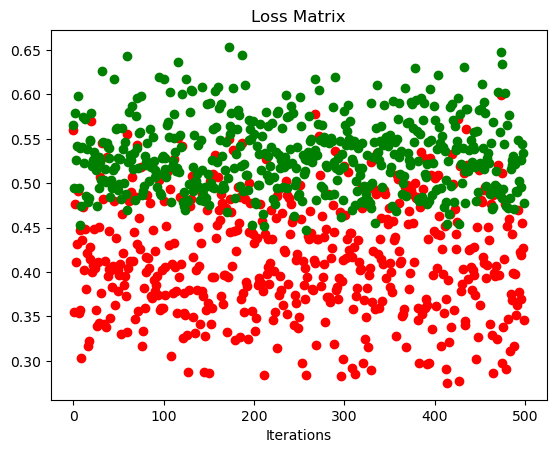

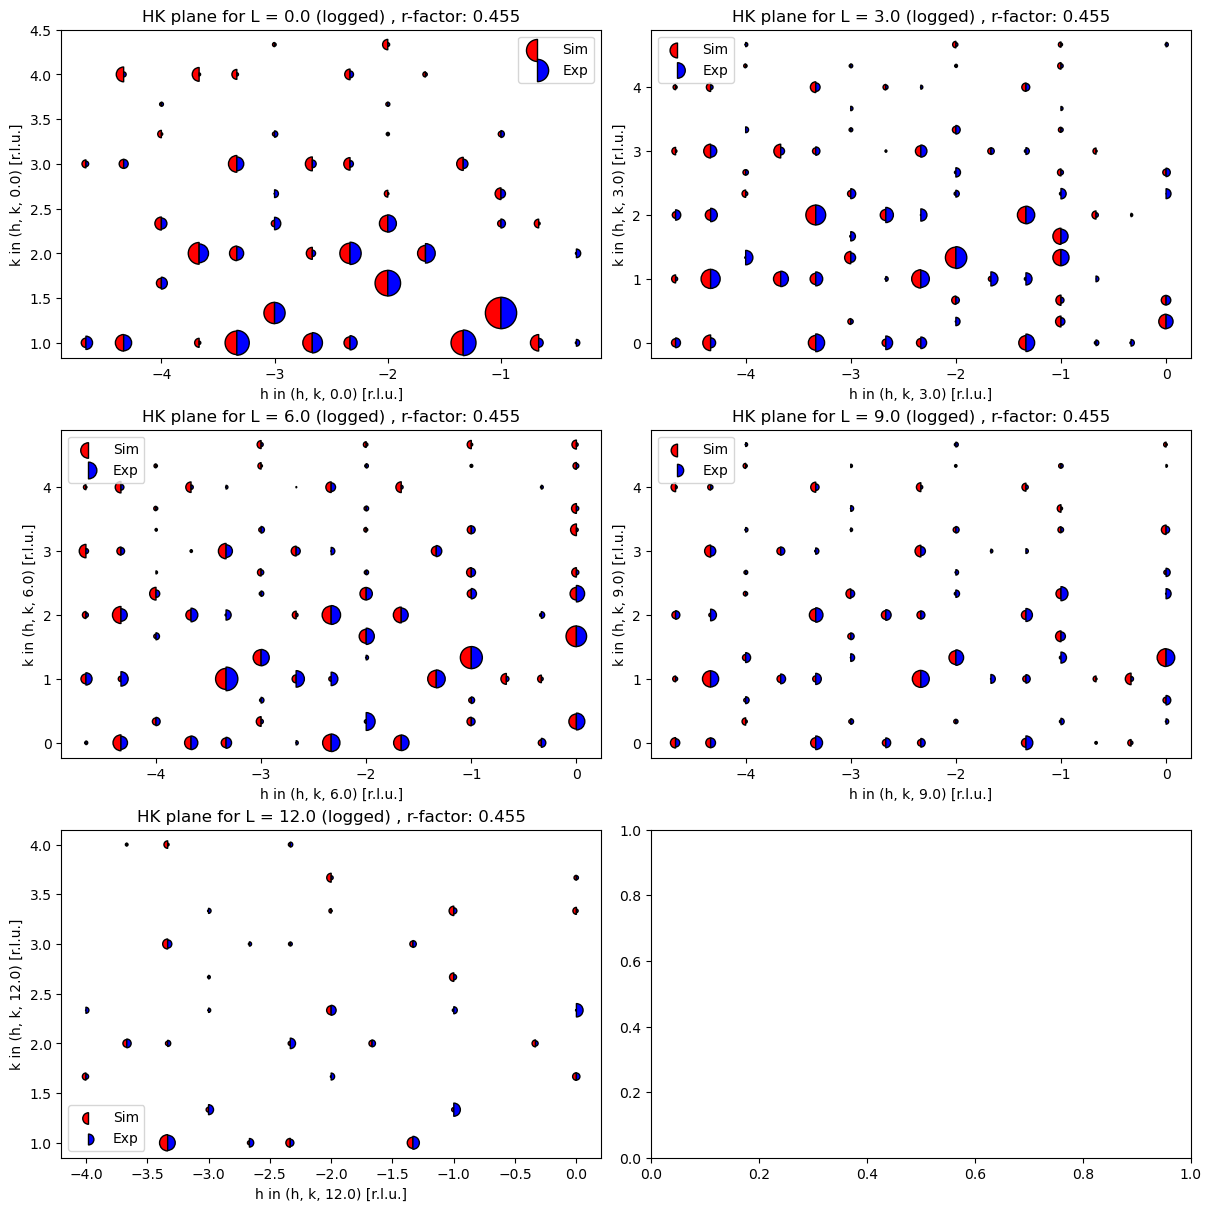

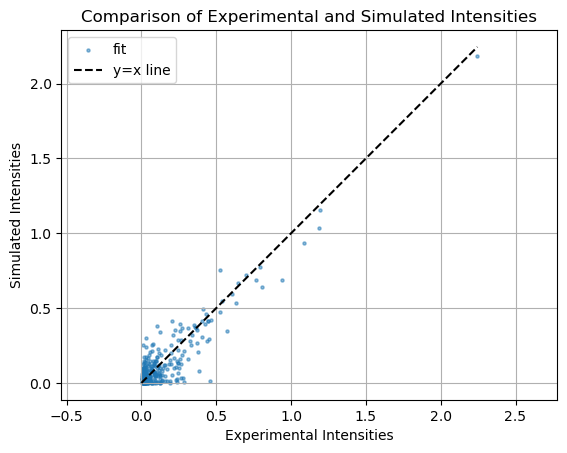

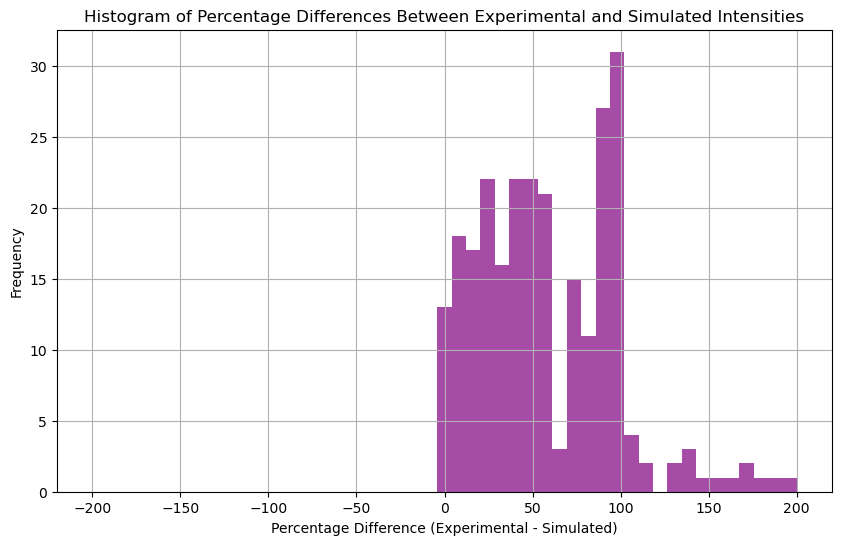

In [7]:
#load file 
number_of_modes = 52
file_name = 'run_2_iters500_epochs1000_lr0.007'
histogram = np.load(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/all_result_matrix.npz')

#extact histogram matrix
histogram_matrix = histogram['histogram_matrix'] # [modes , iterations]
print(histogram_matrix.shape)

hist_matrix = histogram_matrix.T #[iterations, modes]



loss_matrix = histogram['loss_matrix']
r_factors = histogram['r_factors']
iteration = np.arange(0, len(loss_matrix))


plt.scatter(iteration,loss_matrix, label='Loss over iterations', color='red')
plt.title('Loss Matrix')
plt.xlabel('Iterations')

#extract iterations where the loss matrix is less than a certain threshold
threshold = 0.15
filtered_iterations = iteration[loss_matrix < threshold]

# Plot the filtered loss values
plt.scatter(filtered_iterations, loss_matrix[loss_matrix < threshold], label='Filtered Loss', color='blue')

plt.scatter(iteration, r_factors, label='R-factors over iterations', color='green')

#find the index where the min loss matrix value is
min_loss_index = np.argmin(loss_matrix)
print(f"Minimum loss index: {min_loss_index}")
print(f"Minimum loss value: {loss_matrix[min_loss_index]:.3f}") 

min_r_factor_index = np.argmin(r_factors)
print(f"Minimum R-factor index: {min_r_factor_index}")

exp_data , r_factor = calculate_structure_factor(min_loss_index, hist_matrix)
print(f"R-factor: {r_factor:.3f}")

l_values = [0.0, 3.0, 6.0, 9.0, 12.0]

n = len(l_values)
ncols = int(np.ceil(n / 3))
fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12), constrained_layout=True)
axs = axs.flatten()

for i, l in enumerate(l_values):
    plot_plane_sim_vs_exp_DIM3(axs[i], exp_data, r_factor,l, norm_plane=False)

plt.show()

normalised_exp = exp_data['normalised_exp']

x = np.linspace(0 ,np.max(normalised_exp), 100)
y = x
plt.scatter(normalised_exp, exp_data['intensity_sim'], s=5, alpha=0.5 , label='fit')
plt.plot(x , y, color='black', linestyle='--', label='y=x line')
plt.legend()
plt.grid(True)
plt.title('Comparison of Experimental and Simulated Intensities')
plt.xlabel('Experimental Intensities')
plt.ylabel('Simulated Intensities')
plt.axis('equal')
plt.show()


#plot a historgram of the percentage difference in intensity between experimental and simulated
percentage_diff = np.abs(normalised_exp - exp_data['intensity_sim']) / normalised_exp * 100
exp_data['percentage_diff'] = percentage_diff
plt.figure(figsize=(10, 6))
plt.hist(percentage_diff, bins=np.linspace(-200 , 200 , 50), alpha=0.7, color='purple')
plt.title('Histogram of Percentage Differences Between Experimental and Simulated Intensities')
plt.xlabel('Percentage Difference (Experimental - Simulated)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#export hist_matrix as mat file
import scipy.io
scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/results/{file_name}/run2_histogram_matrix.mat', {'histogram_matrix': hist_matrix})